In [1]:
import pandas as pd
from ase.db import connect

db = connect("c2db.db")

data = []
for row in db.select():

    entry = {
        "id": row.id,
        "formula": row.formula,
        "natoms": row.natoms,
        "energy": row.energy,
        **row.key_value_pairs,  # Unpacks calculated properties (gaps, magnetic moments, etc.)
    }
    data.append(entry)

df = pd.DataFrame(data)

# Clean/Inspect DataFrame
print(df.info())
print(df[["formula", "gap", "gap_gw", "efermi"]].head())

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      16905 non-null  int64  
 1   formula                 16905 non-null  str    
 2   natoms                  16905 non-null  int64  
 3   energy                  16905 non-null  float64
 4   folder                  16905 non-null  str    
 5   uid                     16905 non-null  str    
 6   olduid                  16789 non-null  str    
 7   international           16905 non-null  str    
 8   number                  16905 non-null  int64  
 9   has_inversion_symmetry  16905 non-null  bool   
 10  lgnum                   16905 non-null  int64  
 11  layergroup              16905 non-null  str    
 12  bravais_type            16695 non-null  str    
 13  bravais_search          16695 non-null  str    
 14  thickness               16905 non-null  float64
 

In [2]:
df["spin_axis"].notnull() # Check if the 'is_ferroelectric' column exists and has non-null values

0         True
1        False
2        False
3        False
4        False
         ...  
16900    False
16901     True
16902     True
16903    False
16904    False
Name: spin_axis, Length: 16905, dtype: bool

# Task - 0 Exploring Data

In [3]:
df.columns

Index(['id', 'formula', 'natoms', 'energy', 'folder', 'uid', 'olduid',
       'international', 'number', 'has_inversion_symmetry', 'lgnum',
       'layergroup', 'bravais_type', 'bravais_search', 'thickness', 'label',
       'gap_dir_nosoc', 'evac', 'efermi', 'gap', 'gap_dir', 'vbm', 'cbm',
       'evacdiff', 'dipz', 'minhessianeig', 'dyn_stab', 'gap_hse',
       'gap_dir_hse', 'vbm_hse', 'cbm_hse', 'efermi_hse', 'alphax_el',
       'alphay_el', 'alphaz_el', 'alphax_lat', 'alphax', 'alphay_lat',
       'alphay', 'alphaz_lat', 'alphaz', 'emass_cbm', 'emass_vbm',
       'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy', 'ehull', 'hform',
       'cod_id', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u',
       'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u',
       'is_ferroelectric', 'P_spontaneous_norm', 'icsd_id', 'J_u', 'lam_u',
       'A_u', 'spin_u', 'N_nn_u', 'J', 'lam', 'A', 'spin', 'N_nn', 'topology',
       'plasmafrequency_x', 'plasmafrequency_y', 'halfmetal_gap',

In [4]:
cols = df.columns

print(df[cols].head())

   id       formula  natoms      energy  \
0   1     InNaAs2S6      10  -41.329140   
1   2     CuScAs2S6      10  -46.645235   
2   3  Ag2Cr2As4O12      20 -123.723922   
3   4  Ag2Cr2As4O12      20 -124.709924   
4   5    AlLiSb2Te6      10  -35.061072   

                                              folder            uid  \
0  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/I...   1InNaAs2S6-1   
1  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/C...   1CuScAs2S6-1   
2  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...   2AgCrAs2O6-2   
3  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...   2AgCrAs2O6-1   
4  /home/niflheim2/cmr/C2DB-ASR/tree_LDP/ABC2D6/A...  1AlLiSb2Te6-1   

                      olduid international  number  has_inversion_symmetry  \
0     InNaAs2S6-b86d8d87fbda            C2       5                   False   
1     CuScAs2S6-04403e673f20          P312     149                   False   
2  Ag2Cr2As4O12-317a92ccf0bd          P2/c      13                    True   
3 

In [5]:
df.columns

Index(['id', 'formula', 'natoms', 'energy', 'folder', 'uid', 'olduid',
       'international', 'number', 'has_inversion_symmetry', 'lgnum',
       'layergroup', 'bravais_type', 'bravais_search', 'thickness', 'label',
       'gap_dir_nosoc', 'evac', 'efermi', 'gap', 'gap_dir', 'vbm', 'cbm',
       'evacdiff', 'dipz', 'minhessianeig', 'dyn_stab', 'gap_hse',
       'gap_dir_hse', 'vbm_hse', 'cbm_hse', 'efermi_hse', 'alphax_el',
       'alphay_el', 'alphaz_el', 'alphax_lat', 'alphax', 'alphay_lat',
       'alphay', 'alphaz_lat', 'alphaz', 'emass_cbm', 'emass_vbm',
       'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy', 'ehull', 'hform',
       'cod_id', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u',
       'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u',
       'is_ferroelectric', 'P_spontaneous_norm', 'icsd_id', 'J_u', 'lam_u',
       'A_u', 'spin_u', 'N_nn_u', 'J', 'lam', 'A', 'spin', 'N_nn', 'topology',
       'plasmafrequency_x', 'plasmafrequency_y', 'halfmetal_gap',

In [6]:
len(df.columns)

87

In [7]:
analysis_keys = [
    # Structure & Composition
    "formula", "natoms", "thickness", "has_inversion_symmetry", 
    "international", "number", "layergroup", "lgnum", "bravais_type", "bravais_search", "label",
    
    # Energetics & Stability
    "energy", "hform", "ehull", "dyn_stab", "minhessianeig",
    
    # PBE Electronic Properties
    "gap", "gap_dir", "gap_dir_nosoc", "vbm", "cbm", "efermi", "evac", "evacdiff",
    "emass_cbm", "emass_vbm", "halfmetal_gap", "halfmetal_gap_dir", "topology",
    
    # Advanced Band Gaps (HSE & GW)
    "gap_hse", "gap_dir_hse", "vbm_hse", "cbm_hse", "efermi_hse", 
    "halfmetal_gap_hse", "halfmetal_gap_dir_hse",
    "gap_gw", "gap_dir_gw", "vbm_gw", "cbm_gw", "efermi_gw", "E_B",
    
    # Dielectric & Optical
    "dipz", "alphax", "alphay", "alphaz", 
    "alphax_el", "alphay_el", "alphaz_el", 
    "alphax_lat", "alphay_lat", "alphaz_lat", 
    "plasmafrequency_x", "plasmafrequency_y",
    
    # Magnetism (PBE & DFT+U)
    "is_magnetic", "spin_axis", "dE_zx", "dE_zy", "spin", "J", "lam", "A", "N_nn",
    "is_magnetic_u", "magmom_u", "spin_axis_u", "dE_zx_u", "dE_zy_u", 
    "efermi_u", "gap_u", "gap_dir_u", "vbm_u", "cbm_u", 
    "J_u", "lam_u", "A_u", "spin_u", "N_nn_u",
    
    # Ferroelectricity
    "is_ferroelectric", "P_spontaneous_norm"
]

In [8]:
data = df[analysis_keys].copy()

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 16905 non-null  str    
 1   natoms                  16905 non-null  int64  
 2   thickness               16905 non-null  float64
 3   has_inversion_symmetry  16905 non-null  bool   
 4   international           16905 non-null  str    
 5   number                  16905 non-null  int64  
 6   layergroup              16905 non-null  str    
 7   lgnum                   16905 non-null  int64  
 8   bravais_type            16695 non-null  str    
 9   bravais_search          16695 non-null  str    
 10  label                   16766 non-null  str    
 11  energy                  16905 non-null  float64
 12  hform                   16905 non-null  float64
 13  ehull                   16905 non-null  float64
 14  dyn_stab                16905 non-null  str    
 

In [10]:
print("Number of columns in the DataFrame:", len(df.columns))
print("Number of columns for analysis:", len(data.columns))

Number of columns in the DataFrame: 87
Number of columns for analysis: 80


In [11]:
# 1. Dataset where 'E_B' has NO null values
df_eb_notnull =data[data['E_B'].notna()].copy()

# 2. Dataset where 'gap_gw' has NO null values
df_gap_notnull = data[data['gap_gw'].notna()].copy()

# 3. Dataset where BOTH 'E_B' AND 'gap_gw' have NO null values
df_both_notnull = data[data['E_B'].notna() & data['gap_gw'].notna()].copy()

### Up to now :
1. There were 16905 data points. --> data (data set)
2. But 283 entries which have non zero 'E_b' , and 'gap_gw'
3.  Now df_eb_notnull (data set)


# Task - 01 : Division X, y 

In [12]:
df_eb_notnull.info()


<class 'pandas.DataFrame'>
Index: 370 entries, 2764 to 13376
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 370 non-null    str    
 1   natoms                  370 non-null    int64  
 2   thickness               370 non-null    float64
 3   has_inversion_symmetry  370 non-null    bool   
 4   international           370 non-null    str    
 5   number                  370 non-null    int64  
 6   layergroup              370 non-null    str    
 7   lgnum                   370 non-null    int64  
 8   bravais_type            370 non-null    str    
 9   bravais_search          370 non-null    str    
 10  label                   370 non-null    str    
 11  energy                  370 non-null    float64
 12  hform                   370 non-null    float64
 13  ehull                   370 non-null    float64
 14  dyn_stab                370 non-null    str    
 15  

In [13]:
df_both_notnull.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [14]:
df_both_notnull["is_ferroelectric"].notnull().sum()

np.int64(7)

In [15]:
X, y = df_both_notnull.drop(columns=["E_B", "gap_gw"]), df_both_notnull[["E_B", "gap_gw"]]

In [16]:
X.shape, y.shape

((283, 78), (283, 2))

# Tasks - 02: Pase 01, Working on Data Set



In [17]:
corr_01 = y["E_B"].corr(y["gap_gw"])

corr_01

np.float64(0.7307748405589916)

In [18]:
X.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [19]:
y.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   E_B     283 non-null    float64
 1   gap_gw  283 non-null    float64
dtypes: float64(2)
memory usage: 6.6 KB


In [20]:
y[["E_B", "gap_gw"]].head()

,E_B,gap_gw
2764,1.860429,9.598559
2765,1.793056,8.209944
2775,1.352613,2.403058
2782,0.063864,5.398439
2800,0.419845,1.376623


### Distribution of Band Gap

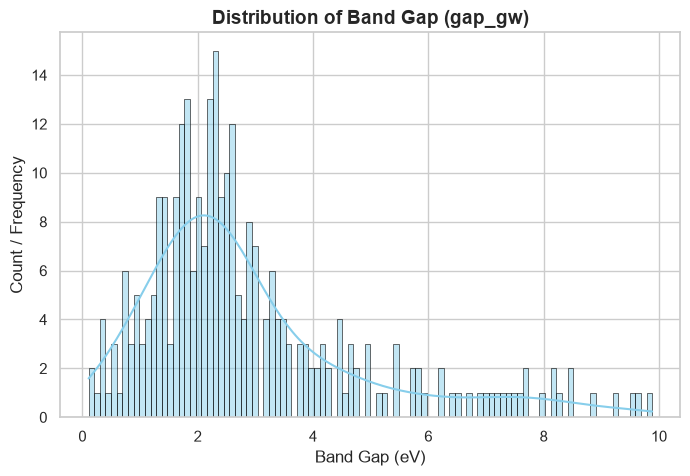

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Plot histogram with smooth density curve (KDE)
# Seaborn automatically drops NaN values
sns.histplot(df_both_notnull['gap_gw'].dropna(), kde=True, bins=100, color='skyblue', edgecolor='black')

plt.title("Distribution of Band Gap (gap_gw)", fontsize=14, fontweight='bold')
plt.xlabel("Band Gap (eV)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)

plt.show()

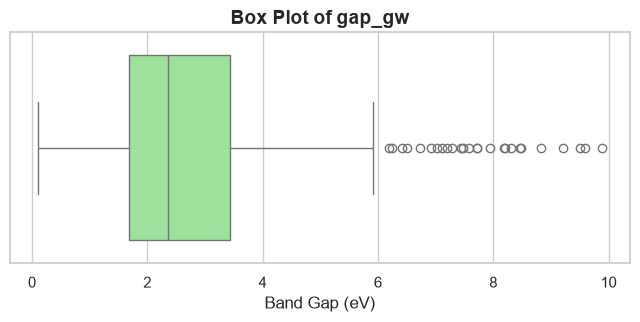

In [22]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df_both_notnull['gap_gw'], color='lightgreen')

plt.title("Box Plot of gap_gw", fontsize=14, fontweight='bold')
plt.xlabel("Band Gap (eV)", fontsize=12)

plt.show()

In [23]:
df_both_notnull["gap_gw"].describe()

count    283.000000
mean       2.901978
std        1.961865
min        0.108102
25%        1.687050
50%        2.353488
75%        3.429068
max        9.883013
Name: gap_gw, dtype: float64

<Figure size 800x300 with 0 Axes>

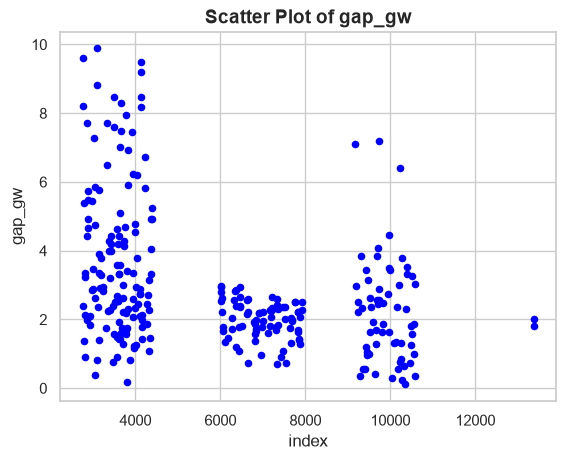

In [24]:
plt.figure(figsize=(8, 3))

y.reset_index().plot.scatter(x='index', y="gap_gw", color='blue')

plt.title("Scatter Plot of gap_gw", fontsize=14, fontweight='bold')

plt.show()

In [25]:
lower= 1.0
upper = 3.5
range_count_gw = df_both_notnull["gap_gw"].between(lower, upper).sum()

percentage = (range_count_gw / len(df_both_notnull)) * 100

print(f"Number of entries with gap_gw between {lower} and {upper} eV: {range_count_gw}")
print(f"Percentage of entries with gap_gw between {lower} and {upper} eV: {percentage:.2f}%")


Number of entries with gap_gw between 1.0 and 3.5 eV: 189
Percentage of entries with gap_gw between 1.0 and 3.5 eV: 66.78%


In [26]:
df_both_notnull["gap_gw"].between(lower, upper).sum()

np.int64(189)

###  Distributions & Correlation Band Gap and Binding Energy

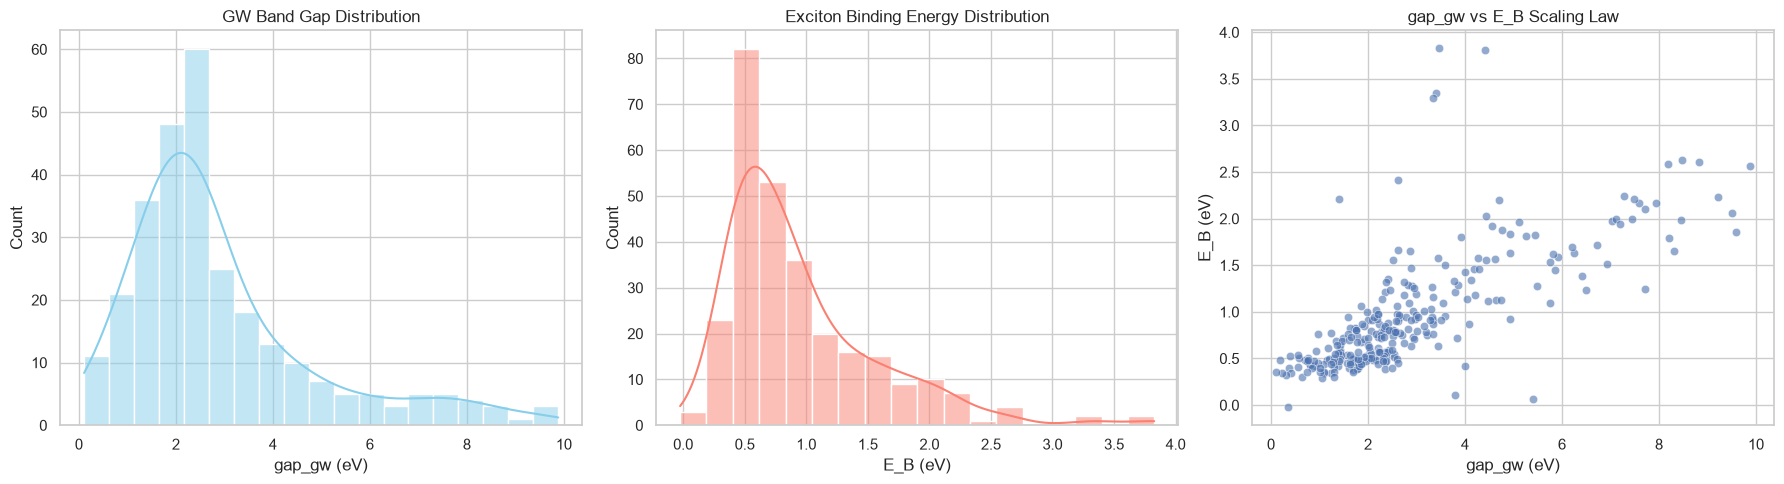

In [27]:
# 2. Plotting Target Distributions & Correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Target 1: GW Gap
sns.histplot(y['gap_gw'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('GW Band Gap Distribution')
axes[0].set_xlabel('gap_gw (eV)')

# Target 2: Exciton Binding Energy
sns.histplot(y['E_B'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Exciton Binding Energy Distribution')
axes[1].set_xlabel('E_B (eV)')

# Target vs Target Relationship
sns.scatterplot(data=y, x='gap_gw', y='E_B', alpha=0.6, ax=axes[2])
axes[2].set_title('gap_gw vs E_B Scaling Law')
axes[2].set_xlabel('gap_gw (eV)')
axes[2].set_ylabel('E_B (eV)')

plt.tight_layout()
plt.show()

In [28]:
X.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 78 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   thickness               283 non-null    float64
 3   has_inversion_symmetry  283 non-null    bool   
 4   international           283 non-null    str    
 5   number                  283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   lgnum                   283 non-null    int64  
 8   bravais_type            283 non-null    str    
 9   bravais_search          283 non-null    str    
 10  label                   283 non-null    str    
 11  energy                  283 non-null    float64
 12  hform                   283 non-null    float64
 13  ehull                   283 non-null    float64
 14  dyn_stab                283 non-null    str    
 15  

In [29]:
X

,formula,natoms,thickness,has_inversion_symmetry,international,number,layergroup,lgnum,bravais_type,bravais_search,...,gap_dir_u,vbm_u,cbm_u,J_u,lam_u,A_u,spin_u,N_nn_u,is_ferroelectric,P_spontaneous_norm
2764,MgCl2,3,2.745812,True,P-3m1,164,p-3m1,72,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2765,MgCl2,3,3.080044,False,P-6m2,187,p-6m2,78,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2775,RuBr2,3,2.633698,True,P-3m1,164,p-3m1,72,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2782,MnCl2,3,2.766866,True,P-3m1,164,p-3m1,72,Hexagonal (hp),Hexagonal,...,4.277521,-7.224414,-3.070012,-0.010393,0.000176,0.001896,2.5,6.0,NaN,NaN
2800,WTe2,3,3.623924,False,P-6m2,187,p-6m2,78,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10567,In2O2,4,4.431604,False,P-6m2,187,p-6m2,78,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10576,F2Ge2,4,4.154893,True,P-3m1,164,p-3m1,72,Hexagonal (hp),Hexagonal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10577,Ge2S2,4,2.563644,False,Pmn2_1,31,pm2_1n,32,Rectangular (op),Rectangular,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,489.761582
13375,P4,4,2.109979,True,Pmna,53,pman,42,Rectangular (op),Rectangular,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# 1. Drop columns that are completely empty (0 non-null values)
X_clean = X.dropna(axis=1, how='all')

# 2. Drop columns where missing values exceed a specific threshold (e.g., >30% missing)
missing_threshold = 0.30
null_fraction = X_clean.isnull().mean()
cols_to_drop = null_fraction[null_fraction > missing_threshold].index

print(f"Dropping {len(cols_to_drop)} sparse columns with >{missing_threshold*100:.0f}% missing values:")
print(list(cols_to_drop))

X_clean = X_clean.drop(columns=cols_to_drop)

Dropping 23 sparse columns with >30% missing values:
['topology', 'spin', 'J', 'lam', 'A', 'N_nn', 'is_magnetic_u', 'magmom_u', 'spin_axis_u', 'dE_zx_u', 'dE_zy_u', 'efermi_u', 'gap_u', 'gap_dir_u', 'vbm_u', 'cbm_u', 'J_u', 'lam_u', 'A_u', 'spin_u', 'N_nn_u', 'is_ferroelectric', 'P_spontaneous_norm']


In [31]:
X_clean.isnull().sum()

formula                    0
natoms                     0
thickness                  0
has_inversion_symmetry     0
international              0
number                     0
layergroup                 0
lgnum                      0
bravais_type               0
bravais_search             0
label                      0
energy                     0
hform                      0
ehull                      0
dyn_stab                   0
minhessianeig              0
gap                        0
gap_dir                    0
gap_dir_nosoc              0
vbm                        0
cbm                        0
efermi                     0
evac                       0
evacdiff                   0
emass_cbm                  0
emass_vbm                  0
gap_hse                    0
gap_dir_hse                0
vbm_hse                    0
cbm_hse                    0
efermi_hse                 0
gap_dir_gw                 0
vbm_gw                     0
cbm_gw                     0
efermi_gw     

In [32]:
from sklearn.impute import SimpleImputer
import numpy as np

num_cols_with_nulls = X_clean.select_dtypes(
    include=[np.number]
).columns[X_clean.select_dtypes(include=[np.number]).isnull().any()]

imputer = SimpleImputer(strategy='median')
X_clean[num_cols_with_nulls] = imputer.fit_transform(X_clean[num_cols_with_nulls])

print(f"\nCleaned feature matrix shape: {X_clean.shape}")


Cleaned feature matrix shape: (283, 51)


In [33]:
# 1. Identifiers / Metadata (High cardinality text — keep for reference, exclude from ML inputs)
id_cols = ['formula', 'label']

# 2. Boolean features
bool_cols = X_clean.select_dtypes(include=['bool']).columns.tolist()

# 3. Categorical / String features
cat_cols = X_clean.select_dtypes(include=['object', 'str']).columns.tolist()
# Remove metadata columns from categorical list if present
cat_cols = [c for c in cat_cols if c not in id_cols]

# 4. Numerical features (int64, float64)
num_cols = X_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"Identifiers ({len(id_cols)}):", id_cols)
print(f"Boolean ({len(bool_cols)}):", bool_cols)
print(f"Categorical ({len(cat_cols)}):", cat_cols)
print(f"Numerical ({len(num_cols)}):", num_cols[:10], "... total:", len(num_cols))

Identifiers (2): ['formula', 'label']
Boolean (1): ['has_inversion_symmetry']
Categorical (7): ['international', 'layergroup', 'bravais_type', 'bravais_search', 'dyn_stab', 'is_magnetic', 'spin_axis']
Numerical (41): ['natoms', 'thickness', 'number', 'lgnum', 'energy', 'hform', 'ehull', 'minhessianeig', 'gap', 'gap_dir'] ... total: 41


### Correlations

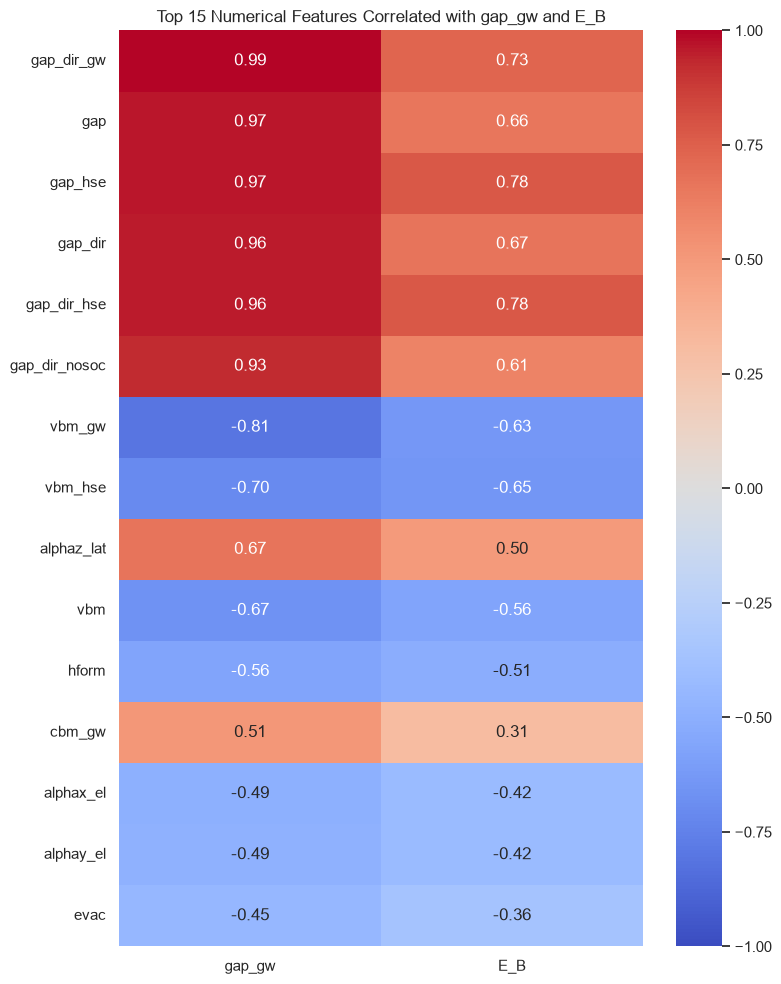


Found 33 highly correlated feature pairs (|r| > 0.85):
  - lgnum <--> number: r = 0.99
  - gap_dir <--> gap: r = 0.98
  - gap_dir_nosoc <--> gap: r = 0.94
  - gap_dir_nosoc <--> gap_dir: r = 0.95
  - efermi <--> vbm: r = 0.87
  - gap_hse <--> gap: r = 0.95
  - gap_hse <--> gap_dir: r = 0.93
  - gap_hse <--> gap_dir_nosoc: r = 0.88
  - gap_dir_hse <--> gap: r = 0.93
  - gap_dir_hse <--> gap_dir: r = 0.94
  - gap_dir_hse <--> gap_dir_nosoc: r = 0.89
  - gap_dir_hse <--> gap_hse: r = 0.98
  - vbm_hse <--> vbm: r = 0.98
  - cbm_hse <--> cbm: r = 0.97
  - efermi_hse <--> efermi: r = 0.91
  - gap_dir_gw <--> gap: r = 0.95
  - gap_dir_gw <--> gap_dir: r = 0.97
  - gap_dir_gw <--> gap_dir_nosoc: r = 0.93
  - gap_dir_gw <--> gap_hse: r = 0.95
  - gap_dir_gw <--> gap_dir_hse: r = 0.96
  - vbm_gw <--> vbm: r = 0.96
  - vbm_gw <--> vbm_hse: r = 0.96
  - cbm_gw <--> cbm: r = 0.93
  - cbm_gw <--> cbm_hse: r = 0.96
  - efermi_gw <--> efermi: r = 0.90
  - efermi_gw <--> efermi_hse: r = 0.88
  - dipz 

In [34]:
# --- Step A: Combine Cleaned Numerical Features with Targets ---
# Assuming y is a DataFrame with columns ['gap_gw', 'E_B']
df_analysis = pd.concat([X_clean[num_cols], y], axis=1)

# Compute Pearson correlation matrix
corr_matrix = df_analysis.corr(method='pearson')

# --- Step B: Correlation of Numerical Features with Targets ---
target_corr = corr_matrix[['gap_gw', 'E_B']].drop(index=['gap_gw', 'E_B'])

# Sort by absolute correlation with GW gap
target_corr_sorted = target_corr.reindex(
    target_corr['gap_gw'].abs().sort_values(ascending=False).index
)

# Plot top 15 correlated features with targets
plt.figure(figsize=(8, 10))
sns.heatmap(target_corr_sorted.head(15), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Top 15 Numerical Features Correlated with gap_gw and E_B')
plt.tight_layout()
plt.show()


# --- Step C: Finding Multicollinear Features (Redundant Inputs) ---
# Find pairs of input features with |correlation| > 0.85
threshold = 0.85
feature_corr = X_clean[num_cols].corr().abs()

# Select upper triangle of correlation matrix
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

# Find features with correlation greater than threshold
high_corr_pairs = [
    (column, row, upper.loc[row, column]) 
    for column in upper.columns 
    for row in upper.index 
    if upper.loc[row, column] > threshold
]

print(f"\nFound {len(high_corr_pairs)} highly correlated feature pairs (|r| > {threshold}):")
for f1, f2, val in high_corr_pairs[:]: 
    print(f"  - {f1} <--> {f2}: r = {val:.2f}")

In [35]:
corr_matrix

,natoms,thickness,number,lgnum,energy,hform,ehull,minhessianeig,gap,gap_dir,...,alphaz_el,alphax_lat,alphay_lat,alphaz_lat,plasmafrequency_x,plasmafrequency_y,dE_zx,dE_zy,E_B,gap_gw
natoms,1.000000,0.611656,-0.327059,-0.319951,-0.434682,0.042363,-0.050022,0.034094,-0.135679,-0.161921,...,0.291577,0.133628,0.216856,0.010135,0.111468,0.111468,-0.006425,-0.006503,-0.142172,-0.160443
thickness,0.611656,1.000000,0.218905,0.213130,-0.080652,-0.007440,-0.147463,0.083183,-0.156949,-0.162077,...,0.584228,0.054842,0.032286,0.030616,0.097036,0.097036,-0.008496,-0.008674,-0.227341,-0.204249
number,-0.327059,0.218905,1.000000,0.993226,0.008442,-0.283969,0.134659,-0.139409,0.116947,0.132726,...,0.083974,-0.024883,-0.190104,0.110591,0.043459,0.043459,-0.006148,-0.006155,0.158675,0.150292
lgnum,-0.319951,0.213130,0.993226,1.000000,0.012264,-0.280164,0.122188,-0.131199,0.127282,0.140157,...,0.080549,-0.017473,-0.167308,0.118455,0.040618,0.040618,-0.004136,-0.004128,0.161992,0.160568
energy,-0.434682,-0.080652,0.008442,0.012264,1.000000,0.365952,-0.176007,0.146792,0.187621,0.179916,...,-0.060335,-0.041273,-0.030264,0.137569,-0.172382,-0.172382,0.009744,0.010045,0.065738,0.174195
hform,0.042363,-0.007440,-0.283969,-0.280164,0.365952,1.000000,0.070080,0.217682,-0.516109,-0.555275,...,0.261489,-0.049168,0.020369,-0.509608,0.048353,0.048353,0.001639,0.001970,-0.509409,-0.562585
ehull,-0.050022,-0.147463,0.134659,0.122188,-0.176007,0.070080,1.000000,-0.400998,-0.150605,-0.174352,...,-0.116368,-0.003010,-0.053909,-0.025030,0.134244,0.134244,-0.102413,-0.101672,0.052198,-0.105095
minhessianeig,0.034094,0.083183,-0.139409,-0.131199,0.146792,0.217682,-0.400998,1.000000,-0.023870,-0.021866,...,0.138168,0.020274,0.043032,0.052503,-0.003204,-0.003204,0.004659,0.004716,-0.194108,-0.097710
gap,-0.135679,-0.156949,0.116947,0.127282,0.187621,-0.516109,-0.150605,-0.023870,1.000000,0.981557,...,-0.366943,-0.075240,-0.101503,0.662294,-0.065738,-0.065738,-0.029514,-0.029743,0.664027,0.968240
gap_dir,-0.161921,-0.162077,0.132726,0.140157,0.179916,-0.555275,-0.174352,-0.021866,0.981557,1.000000,...,-0.371046,-0.087912,-0.119900,0.661396,-0.075476,-0.075476,-0.021942,-0.022214,0.666185,0.958804


# Improvements - 03/08/2026

- Improvements in the Data columns (inclusion of some excluded columns)
- 

In [36]:
df_filtered_16_to_35 = df_both_notnull[df_both_notnull["gap_gw"].between(1, 3.5)].copy()

In [37]:
df_filtered_16_to_35.info()

<class 'pandas.DataFrame'>
Index: 189 entries, 2775 to 13376
Data columns (total 80 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 189 non-null    str    
 1   natoms                  189 non-null    int64  
 2   thickness               189 non-null    float64
 3   has_inversion_symmetry  189 non-null    bool   
 4   international           189 non-null    str    
 5   number                  189 non-null    int64  
 6   layergroup              189 non-null    str    
 7   lgnum                   189 non-null    int64  
 8   bravais_type            189 non-null    str    
 9   bravais_search          189 non-null    str    
 10  label                   189 non-null    str    
 11  energy                  189 non-null    float64
 12  hform                   189 non-null    float64
 13  ehull                   189 non-null    float64
 14  dyn_stab                189 non-null    str    
 15  

In [38]:
corre_02 = df_filtered_16_to_35[["gap_gw", "E_B"]].corr()
corre_02

,gap_gw,E_B
gap_gw,1.000000,0.517342
E_B,0.517342,1.000000


Text(0, 0.5, 'E_B (eV)')

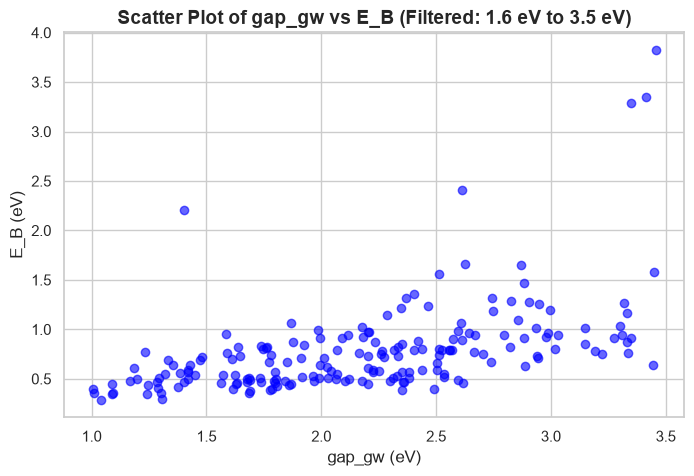

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df_filtered_16_to_35["gap_gw"], df_filtered_16_to_35["E_B"], alpha=0.6, color='blue')
plt.title("Scatter Plot of gap_gw vs E_B (Filtered: 1.6 eV to 3.5 eV)", fontsize=14, fontweight='bold')
plt.xlabel("gap_gw (eV)", fontsize=12)
plt.ylabel("E_B (eV)", fontsize=12)

In [40]:
column_to_keep= [
    'formula', 'natoms', 'energy','number', 'has_inversion_symmetry', 'lgnum',
    'layergroup', 'bravais_type', 'bravais_search', 'thickness', 'evac', 'dipz', 
    'minhessianeig', 'dyn_stab','alphax_el','alphay_el', 'alphaz_el', 'alphax_lat', 
    'alphax', 'alphay_lat', 'alphay', 'alphaz_lat', 'alphaz', 'emass_cbm', 'emass_vbm',
    'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy', 'ehull', 'hform',
    'is_ferroelectric', 'P_spontaneous_norm','J', 'lam', 'A',
    'spin', 'N_nn', 'topology',
    'plasmafrequency_x', 'plasmafrequency_y', 'halfmetal_gap',
    'halfmetal_gap_dir', 'gap_gw', 'vbm_gw', 'cbm_gw',
    'efermi_gw','E_B'
]

In [41]:
new_df = df[column_to_keep]

In [42]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16905 entries, 0 to 16904
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 16905 non-null  str    
 1   natoms                  16905 non-null  int64  
 2   energy                  16905 non-null  float64
 3   number                  16905 non-null  int64  
 4   has_inversion_symmetry  16905 non-null  bool   
 5   lgnum                   16905 non-null  int64  
 6   layergroup              16905 non-null  str    
 7   bravais_type            16695 non-null  str    
 8   bravais_search          16695 non-null  str    
 9   thickness               16905 non-null  float64
 10  evac                    8699 non-null   float64
 11  dipz                    8699 non-null   float64
 12  minhessianeig           8149 non-null   float64
 13  dyn_stab                16905 non-null  str    
 14  alphax_el               5352 non-null   float64
 

In [43]:
new_df = new_df.dropna(subset=['E_B', 'gap_gw']).copy() 

In [44]:
new_df.info()

<class 'pandas.DataFrame'>
Index: 283 entries, 2764 to 13376
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 283 non-null    str    
 1   natoms                  283 non-null    int64  
 2   energy                  283 non-null    float64
 3   number                  283 non-null    int64  
 4   has_inversion_symmetry  283 non-null    bool   
 5   lgnum                   283 non-null    int64  
 6   layergroup              283 non-null    str    
 7   bravais_type            283 non-null    str    
 8   bravais_search          283 non-null    str    
 9   thickness               283 non-null    float64
 10  evac                    283 non-null    float64
 11  dipz                    283 non-null    float64
 12  minhessianeig           283 non-null    float64
 13  dyn_stab                283 non-null    str    
 14  alphax_el               283 non-null    float64
 15  

In [45]:
# Select columns with string or object data types
str_cols = new_df.select_dtypes(include=['object', 'string']).columns.tolist()

print(str_cols)
print(len(str_cols))

['formula', 'layergroup', 'bravais_type', 'bravais_search', 'dyn_stab', 'is_magnetic', 'spin_axis', 'is_ferroelectric', 'topology']
9


In [46]:
new_df[str_cols].head()

,formula,layergroup,bravais_type,bravais_search,dyn_stab,is_magnetic,spin_axis,is_ferroelectric,topology
2764,MgCl2,p-3m1,Hexagonal (hp),Hexagonal,Yes,False,z,NaN,NaN
2765,MgCl2,p-6m2,Hexagonal (hp),Hexagonal,No,False,z,NaN,NaN
2775,RuBr2,p-3m1,Hexagonal (hp),Hexagonal,Yes,False,z,NaN,NaN
2782,MnCl2,p-3m1,Hexagonal (hp),Hexagonal,Yes,True,z,NaN,NaN
2800,WTe2,p-6m2,Hexagonal (hp),Hexagonal,Yes,False,z,NaN,NaN


In [47]:
for element in str_cols:
    print(f"Unique values in column '{element}':")
    print(new_df[element].unique())
    print("\n")

Unique values in column 'formula':
<StringArray>
[ 'MgCl2',  'RuBr2',  'MnCl2',   'WTe2',   'PbI2',  'MoSe2',  'ZrTe2',
   'ZrO2',  'ZrCl2',  'CdBr2',
 ...
 'Pb2Te2',     'BP',    'GaP',  'Cu2S2',  'Sc2S2',  'In2O2',  'F2Ge2',
  'Ge2S2',     'P4',    'As4']
Length: 218, dtype: str


Unique values in column 'layergroup':
<StringArray>
['p-3m1', 'p-6m2', 'p3m1', 'pm2_1n', 'p4/nmm', 'p2/m11', 'pman']
Length: 7, dtype: str


Unique values in column 'bravais_type':
<StringArray>
['Hexagonal (hp)', 'Rectangular (op)', 'Square (tp)']
Length: 3, dtype: str


Unique values in column 'bravais_search':
<StringArray>
['Hexagonal', 'Rectangular', 'Square']
Length: 3, dtype: str


Unique values in column 'dyn_stab':
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Unique values in column 'is_magnetic':
[False True]


Unique values in column 'spin_axis':
<StringArray>
['z', 'x', 'y']
Length: 3, dtype: str


Unique values in column 'is_ferroelectric':
[nan True]


Unique values in column 'topology'

In [48]:
from sklearn.preprocessing import OrdinalEncoder
df_encoded = new_df.copy()

# ---------------------------------------------------------
# 1. Binary & Boolean Mapping (In-place to 0 and 1)
# ---------------------------------------------------------
# Map 'Yes'/'No'
df_encoded['dyn_stab'] = df_encoded['dyn_stab'].map({'Yes': 1, 'No': 0})
df_encoded['has_inversion_symmetry'] = df_encoded['has_inversion_symmetry'].map({True: 1, False: 0})


# Convert Booleans with NaNs (NaN/False -> 0, True -> 1)
bool_cols = ['is_magnetic','is_ferroelectric']
for col in bool_cols:
    df_encoded[col] = df_encoded[col].fillna(0).astype(int)

# ---------------------------------------------------------
# 2. Handle Redundancy
# ---------------------------------------------------------
# 'bravais_search' and 'bravais_type' contain identical information
df_encoded = df_encoded.drop(columns=['bravais_search'])

# ---------------------------------------------------------
# 3. Categorical Encoding for Multi-Class Columns
# ---------------------------------------------------------
multi_class_cols = ['layergroup', 'bravais_type', 'spin_axis', 'topology']

# Option A: Ordinal Encoding (Best for Tree models: XGBoost, Random Forest)
# Fill NaNs with a 'Missing' string category first
df_encoded[multi_class_cols] = df_encoded[multi_class_cols].fillna('Missing')

encoder = OrdinalEncoder()
df_encoded[multi_class_cols] = encoder.fit_transform(df_encoded[multi_class_cols]).astype(int)

# ---------------------------------------------------------
# Optional Check
# ---------------------------------------------------------
print(df_encoded.dtypes)

formula                       str
natoms                      int64
energy                    float64
number                      int64
has_inversion_symmetry      int64
lgnum                       int64
layergroup                  int64
bravais_type                int64
thickness                 float64
evac                      float64
dipz                      float64
minhessianeig             float64
dyn_stab                    int64
alphax_el                 float64
alphay_el                 float64
alphaz_el                 float64
alphax_lat                float64
alphax                    float64
alphay_lat                float64
alphay                    float64
alphaz_lat                float64
alphaz                    float64
emass_cbm                 float64
emass_vbm                 float64
is_magnetic                 int64
spin_axis                   int64
dE_zx                     float64
dE_zy                     float64
ehull                     float64
hform         

In [49]:
df_encoded.to_csv("cleaned_data.csv", index=False)

In [50]:
# Print the mapping for each column
for col_name, categories in zip(multi_class_cols, encoder.categories_):
    print(f"--- {col_name} ---")
    for code, category in enumerate(categories):
        print(f"  {code} -> {category}")
    print()

--- layergroup ---
  0 -> p-3m1
  1 -> p-6m2
  2 -> p2/m11
  3 -> p3m1
  4 -> p4/nmm
  5 -> pm2_1n
  6 -> pman

--- bravais_type ---
  0 -> Hexagonal (hp)
  1 -> Rectangular (op)
  2 -> Square (tp)

--- spin_axis ---
  0 -> x
  1 -> y
  2 -> z

--- topology ---
  0 -> Missing
  1 -> Trivial
  2 -> Z2=1
  3 -> Z2=1,C_M=3



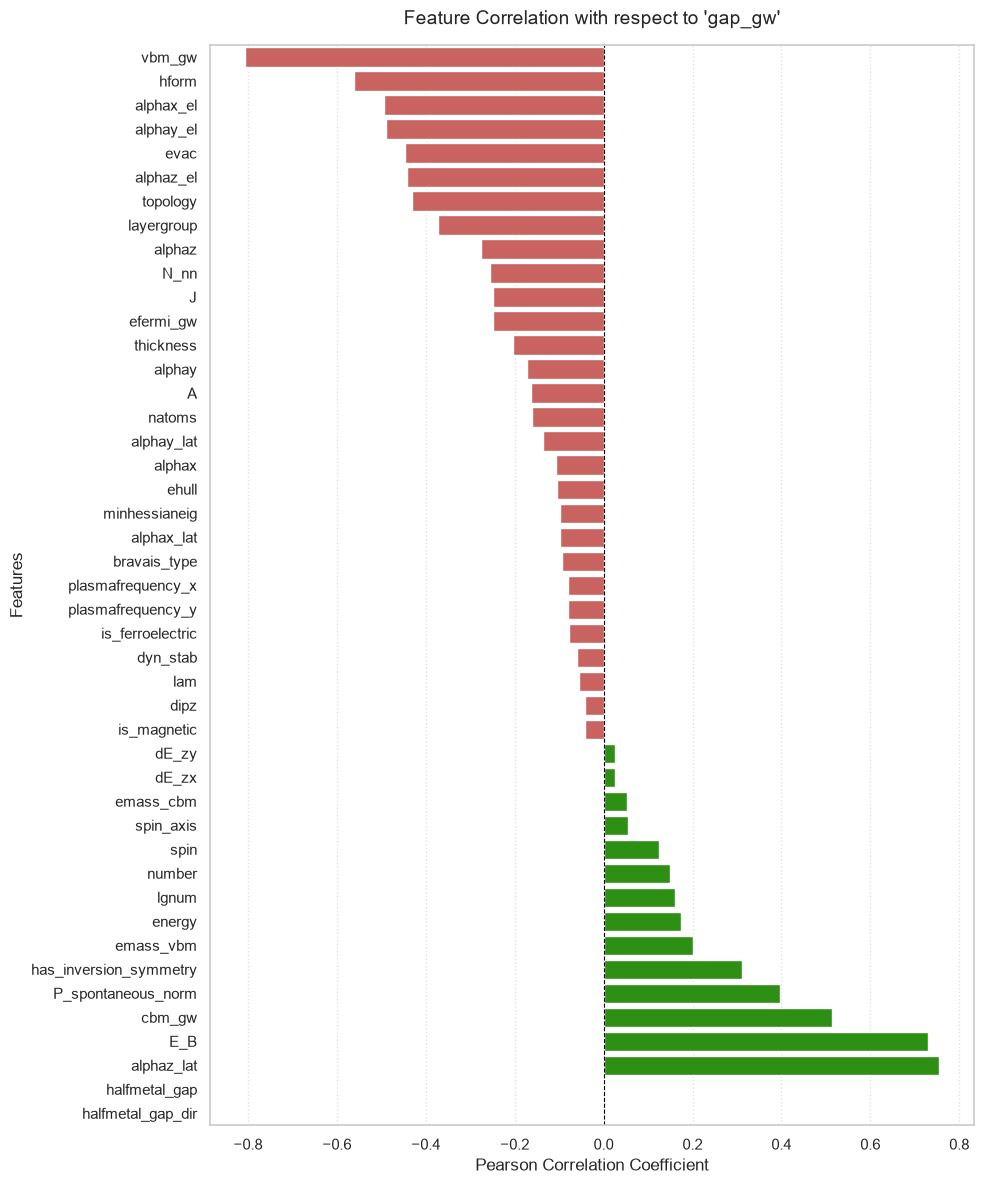

In [51]:
# 1. Compute Pearson correlation with respect to 'gap_gw'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = df_encoded.corr(numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw'", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

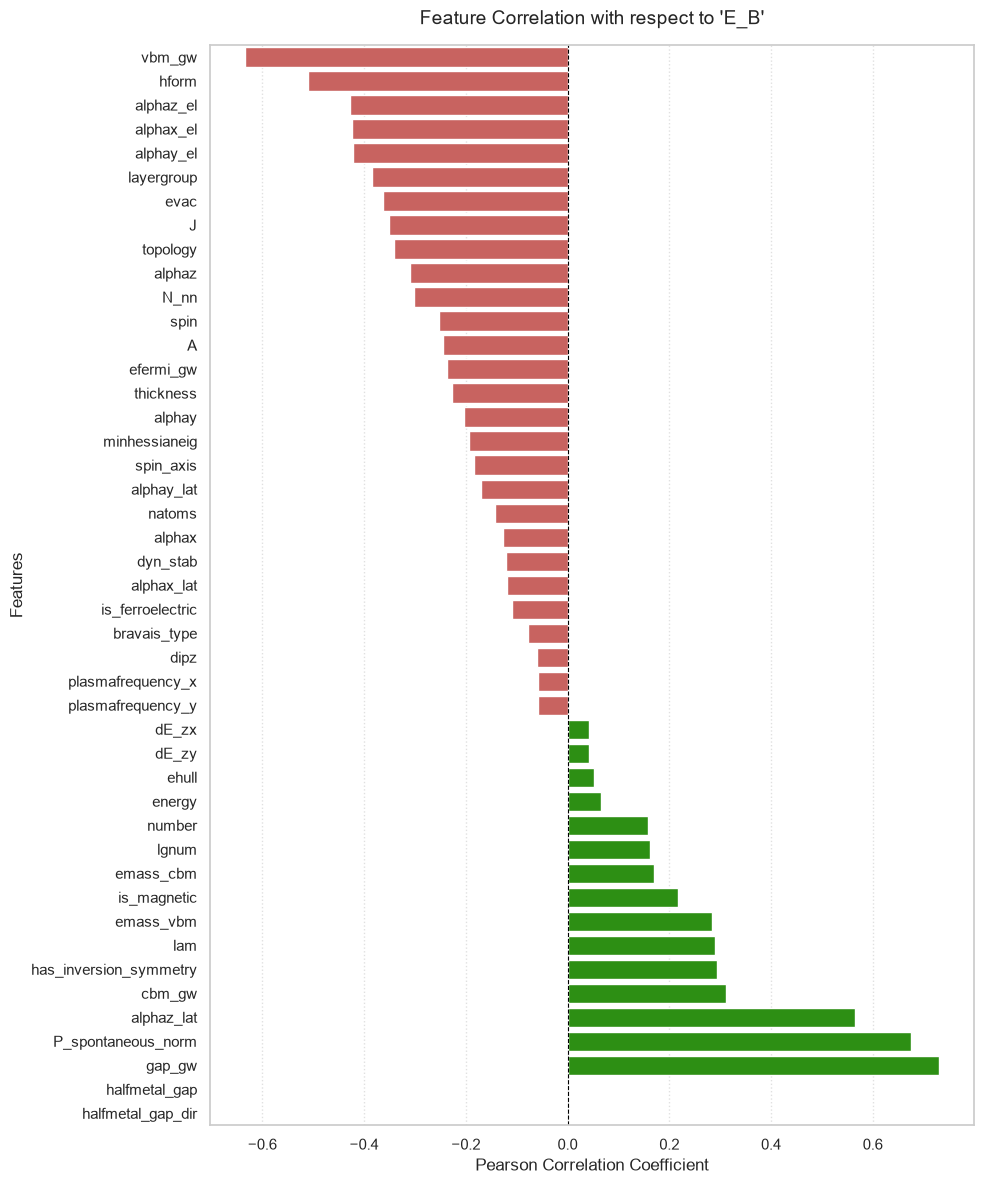

In [52]:
# 1. Compute Pearson correlation with respect to 'E_B'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = df_encoded.corr(numeric_only=True)['E_B'].drop('E_B')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'E_B'", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Spearman Correlation

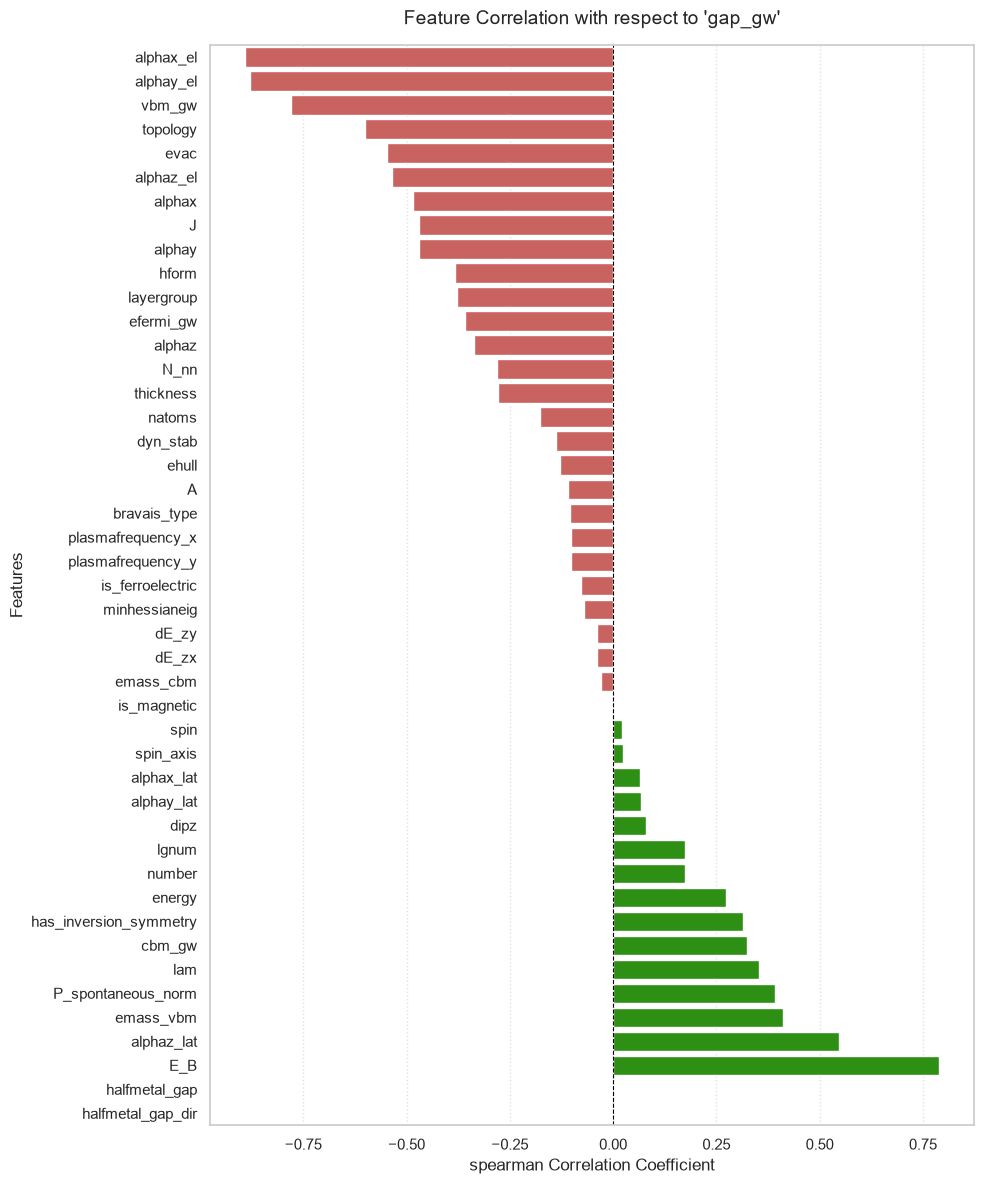

In [53]:
# 1. Compute Spearman correlation with respect to 'gap_gw'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = df_encoded.corr(method='spearman', numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw'", fontsize=14, pad=15)
plt.xlabel("spearman Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

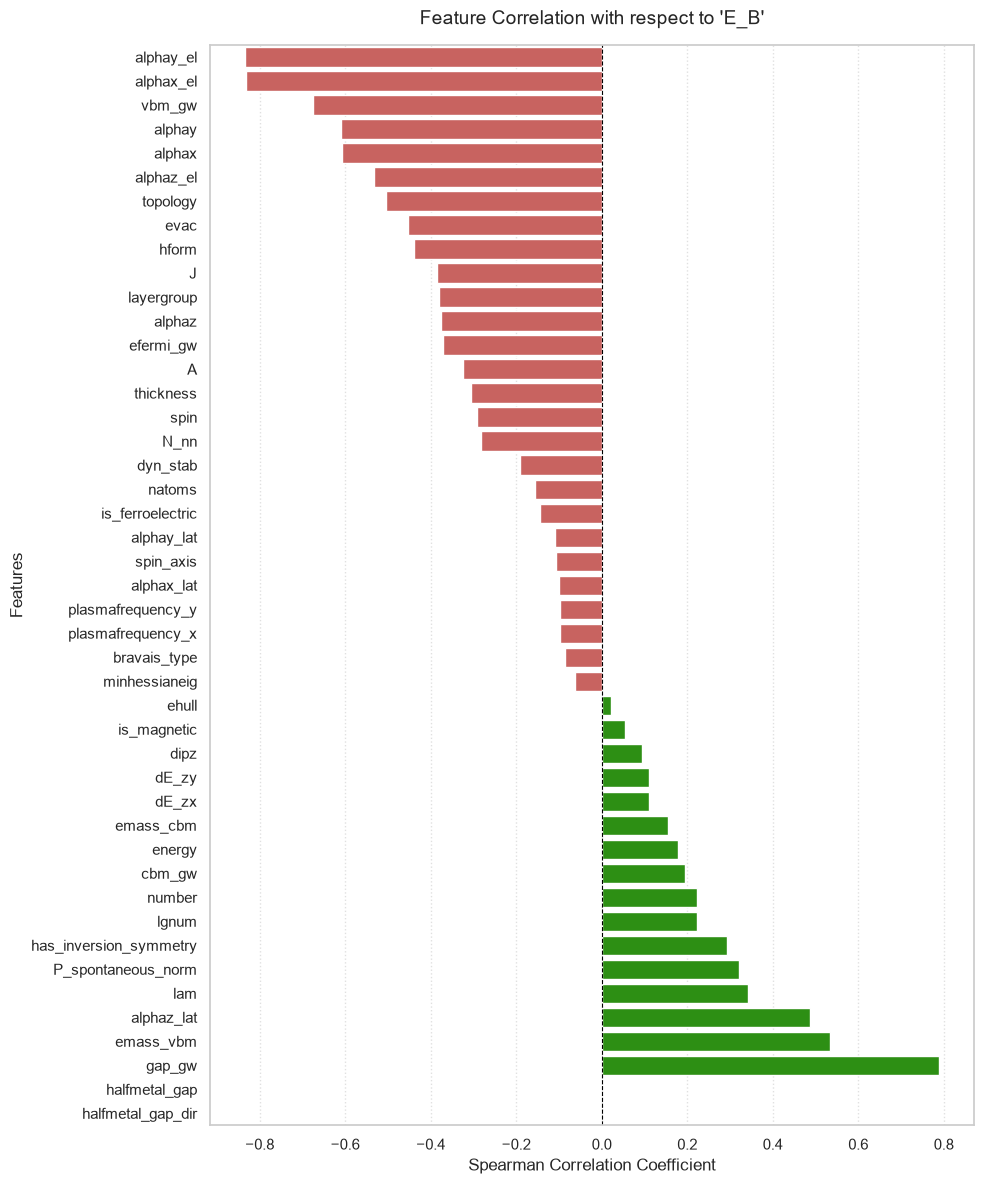

In [54]:
# 1. Compute Spearman correlation with respect to 'E_B'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = df_encoded.corr(method='spearman', numeric_only=True)['E_B'].drop('E_B')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'E_B'", fontsize=14, pad=15)
plt.xlabel("Spearman Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [55]:
df_encoded[["gap_gw", "E_B"]].corr(method='spearman')

,gap_gw,E_B
gap_gw,1.000000,0.789473
E_B,0.789473,1.000000


In [56]:
df_encoded[["gap_gw", "E_B"]].corr()

,gap_gw,E_B
gap_gw,1.000000,0.730775
E_B,0.730775,1.000000


Regression Slope: 2.3063
95% Confidence Interval for Slope: [2.0533, 2.5592]
R-squared: 0.5340


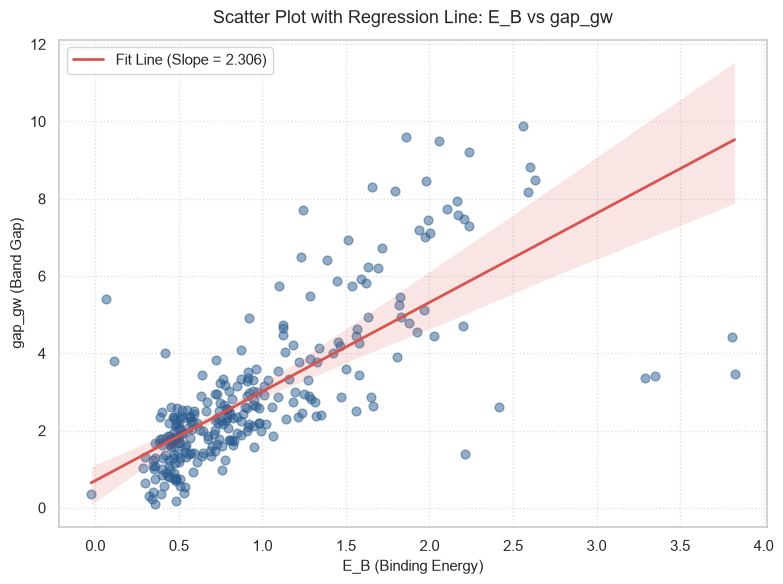

In [57]:
from scipy import stats


x_p = df_encoded['E_B']
y_p = df_encoded['gap_gw']

# 2. Calculate Linear Regression Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x_p, y_p)

# Compute 95% Confidence Interval for the Slope
# Degrees of freedom = N - 2
df_degree = len(x_p) - 2
t_crit = stats.t.ppf(0.975, df_degree)  # Critical value for 95% two-tailed CI
ci_lower = slope - (t_crit * std_err)
ci_upper = slope + (t_crit * std_err)


print(f"Regression Slope: {slope:.4f}")
print(f"95% Confidence Interval for Slope: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"R-squared: {r_value**2:.4f}")

# 3. Create the Scatter Plot with Regression Line & CI Shading
plt.figure(figsize=(8, 6))

# regplot calculates and shades the 95% Confidence Interval band by default (ci=95)
sns.regplot(
    data=df_encoded,
    x='E_B',
    y='gap_gw',
    ci=95,
    scatter_kws={'alpha': 0.5, 'color': '#2b5c8f', 's': 40},
    line_kws={
        'color': '#d9534f',
        'linewidth': 2,
        'label': f'Fit Line (Slope = {slope:.3f})',
    },
)

# Customize plot aesthetics
plt.title(
    'Scatter Plot with Regression Line: E_B vs gap_gw', fontsize=13, pad=12
)
plt.xlabel('E_B (Binding Energy)', fontsize=11)
plt.ylabel('gap_gw (Band Gap)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Regression Slope: 0.6765
95% Confidence Interval for Slope: [0.5151, 0.8380]
R-squared: 0.2676


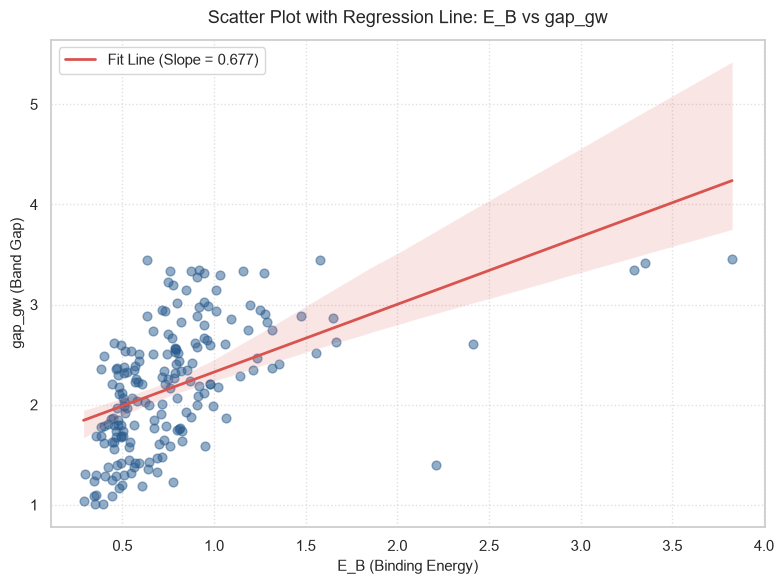

In [58]:
from scipy import stats


temp = df_encoded[df_encoded['gap_gw'].between(1, 3.5)]
x_p = temp['E_B']
y_p = temp['gap_gw']

# 2. Calculate Linear Regression Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x_p, y_p)

# Compute 95% Confidence Interval for the Slope
# Degrees of freedom = N - 2
df_degree = len(x_p) - 2
t_crit = stats.t.ppf(0.975, df_degree)  # Critical value for 95% two-tailed CI
ci_lower = slope - (t_crit * std_err)
ci_upper = slope + (t_crit * std_err)


print(f"Regression Slope: {slope:.4f}")
print(f"95% Confidence Interval for Slope: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"R-squared: {r_value**2:.4f}")

# 3. Create the Scatter Plot with Regression Line & CI Shading
plt.figure(figsize=(8, 6))

# regplot calculates and shades the 95% Confidence Interval band by default (ci=95)
sns.regplot(
    data=temp,
    x='E_B',
    y='gap_gw',
    ci=95,
    scatter_kws={'alpha': 0.5, 'color': '#2b5c8f', 's': 40},
    line_kws={
        'color': '#d9534f',
        'linewidth': 2,
        'label': f'Fit Line (Slope = {slope:.3f})',
    },
)

# Customize plot aesthetics
plt.title(
    'Scatter Plot with Regression Line: E_B vs gap_gw', fontsize=13, pad=12
)
plt.xlabel('E_B (Binding Energy)', fontsize=11)
plt.ylabel('gap_gw (Band Gap)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [59]:
corr_matrix = df_encoded.drop(columns=["formula"]).corr()

In [60]:
corr_matrix.to_csv("correlation_matrix_with_encoded_features.csv", index=True)

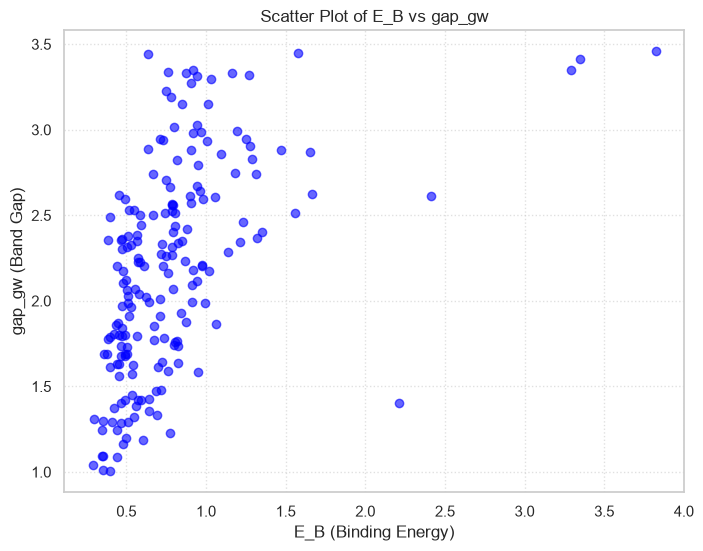

In [61]:
plt.figure(figsize=(8, 6))

# Ensure x is E_B and y is gap_gw
plt.scatter(
    df_filtered_16_to_35['E_B'], 
    df_filtered_16_to_35['gap_gw'], 
    alpha=0.6, 
    color='blue'
)

plt.xlabel('E_B (Binding Energy)') # X-axis: 1.0 to 3.5
plt.ylabel('gap_gw (Band Gap)')      # Y-axis: ~1 to 10
plt.title('Scatter Plot of E_B vs gap_gw')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Text(0, 0.5, 'E_B (eV)')

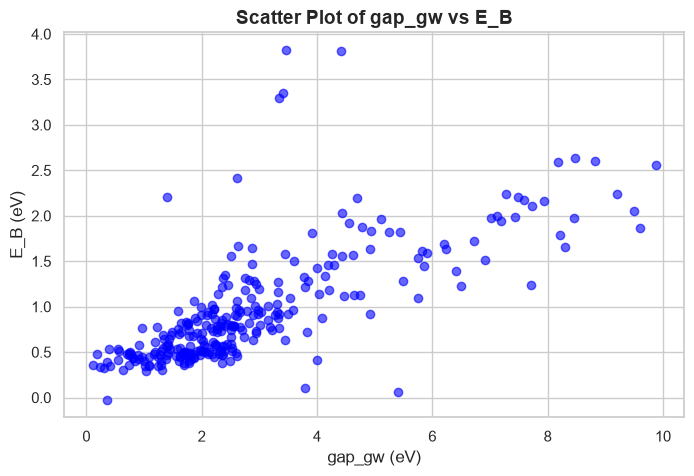

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(df_both_notnull["gap_gw"], df_both_notnull["E_B"], alpha=0.6, color='blue')
plt.title("Scatter Plot of gap_gw vs E_B", fontsize=14, fontweight='bold')
plt.xlabel("gap_gw (eV)", fontsize=12)
plt.ylabel("E_B (eV)", fontsize=12)

Text(0, 0.5, 'E_B (eV)')

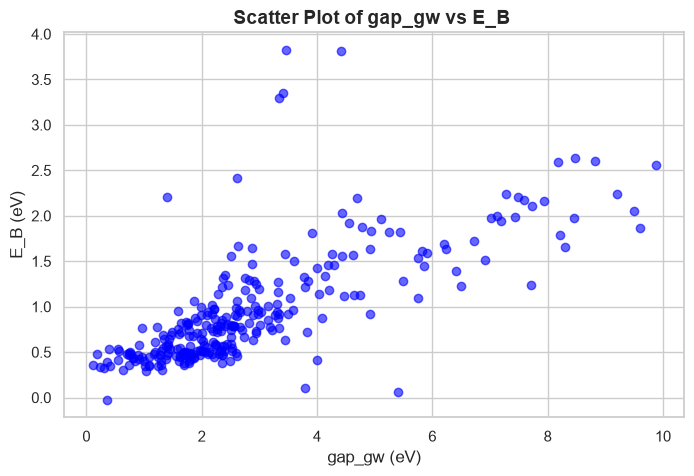

In [63]:
plt.figure(figsize=(8, 5))

plt.scatter(df_encoded["gap_gw"], df_encoded["E_B"], alpha=0.6, color='blue')
plt.title("Scatter Plot of gap_gw vs E_B ", fontsize=14, fontweight='bold')
plt.xlabel("gap_gw (eV)", fontsize=12)
plt.ylabel("E_B (eV)", fontsize=12)

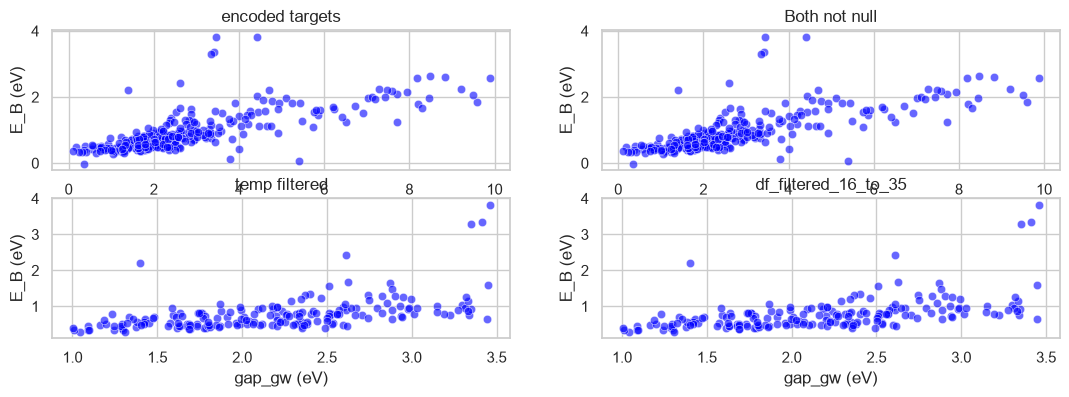

In [64]:
# 2. Plotting Target Distributions & Correlation
fig, axes = plt.subplots(2, 2, figsize=(13, 4))

# Target 1: GW Gap
sns.scatterplot(x=df_encoded['gap_gw'], y=df_encoded['E_B'], alpha=0.6, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('encoded targets')
axes[0, 0].set_xlabel('gap_gw (eV)')
axes[0, 0].set_ylabel('E_B (eV)')

sns.scatterplot(x=df_both_notnull['gap_gw'], y=df_both_notnull['E_B'], alpha=0.6, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Both not null')
axes[0, 1].set_xlabel('gap_gw (eV)')
axes[0, 1].set_ylabel('E_B (eV)')


sns.scatterplot(x=temp['gap_gw'], y=temp['E_B'], alpha=0.6, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('temp filtered')
axes[1, 0].set_xlabel('gap_gw (eV)')
axes[1, 0].set_ylabel('E_B (eV)')

sns.scatterplot(x=df_filtered_16_to_35['gap_gw'], y=df_filtered_16_to_35['E_B'], alpha=0.6, ax=axes[1, 1], color='blue')
axes[1, 1].set_title('df_filtered_16_to_35')
axes[1, 1].set_xlabel('gap_gw (eV)')
axes[1, 1].set_ylabel('E_B (eV)')

plt.show()

Regression Slope: 0.2024
95% Confidence Interval for Slope: [-0.6506, 1.0555]
R-squared: 0.0104


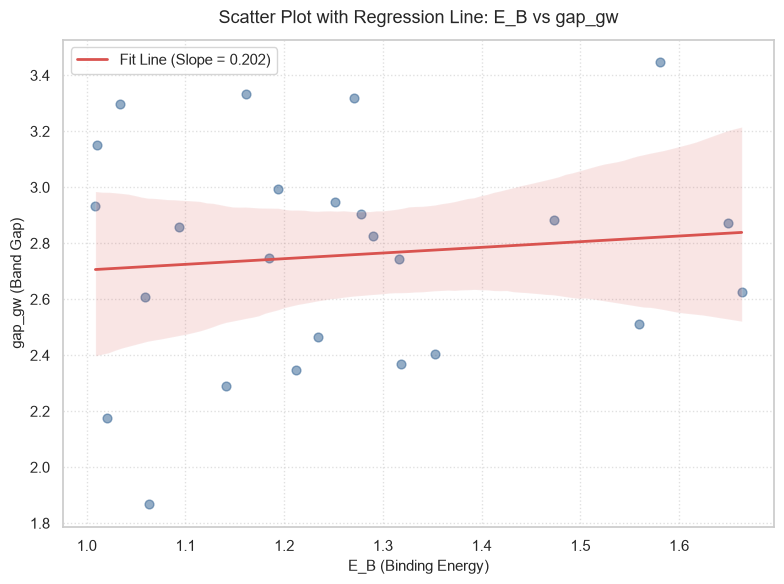

In [65]:
temp = df_encoded[df_encoded['gap_gw'].between(1, 3.5)]
temp = temp[temp['E_B'].between(1, 2)]
x_p = temp['E_B']
y_p = temp['gap_gw']

# 2. Calculate Linear Regression Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(x_p, y_p)

# Compute 95% Confidence Interval for the Slope
# Degrees of freedom = N - 2
df_degree = len(x_p) - 2
t_crit = stats.t.ppf(0.975, df_degree)  # Critical value for 95% two-tailed CI
ci_lower = slope - (t_crit * std_err)
ci_upper = slope + (t_crit * std_err)


print(f"Regression Slope: {slope:.4f}")
print(f"95% Confidence Interval for Slope: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"R-squared: {r_value**2:.4f}")

# 3. Create the Scatter Plot with Regression Line & CI Shading
plt.figure(figsize=(8, 6))

# regplot calculates and shades the 95% Confidence Interval band by default (ci=95)
sns.regplot(
    data=temp,
    x='E_B',
    y='gap_gw',
    ci=95,
    scatter_kws={'alpha': 0.5, 'color': '#2b5c8f', 's': 40},
    line_kws={
        'color': '#d9534f',
        'linewidth': 2,
        'label': f'Fit Line (Slope = {slope:.3f})',
    },
)

# Customize plot aesthetics
plt.title(
    'Scatter Plot with Regression Line: E_B vs gap_gw', fontsize=13, pad=12
)
plt.xlabel('E_B (Binding Energy)', fontsize=11)
plt.ylabel('gap_gw (Band Gap)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [66]:
temp1 = df_encoded[df_encoded['E_B'].between(0, 2)]
temp1 = temp1[temp1['gap_gw'].between(1, 3.5)]

In [67]:
temp1.info()

<class 'pandas.DataFrame'>
Index: 184 entries, 2775 to 13376
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 184 non-null    str    
 1   natoms                  184 non-null    int64  
 2   energy                  184 non-null    float64
 3   number                  184 non-null    int64  
 4   has_inversion_symmetry  184 non-null    int64  
 5   lgnum                   184 non-null    int64  
 6   layergroup              184 non-null    int64  
 7   bravais_type            184 non-null    int64  
 8   thickness               184 non-null    float64
 9   evac                    184 non-null    float64
 10  dipz                    184 non-null    float64
 11  minhessianeig           184 non-null    float64
 12  dyn_stab                184 non-null    int64  
 13  alphax_el               184 non-null    float64
 14  alphay_el               184 non-null    float64
 15  

Text(0.5, 1.0, 'Scatter Plot of E_B vs gap_gw (Filtered: 1.0 eV to 3.5 eV for both)')

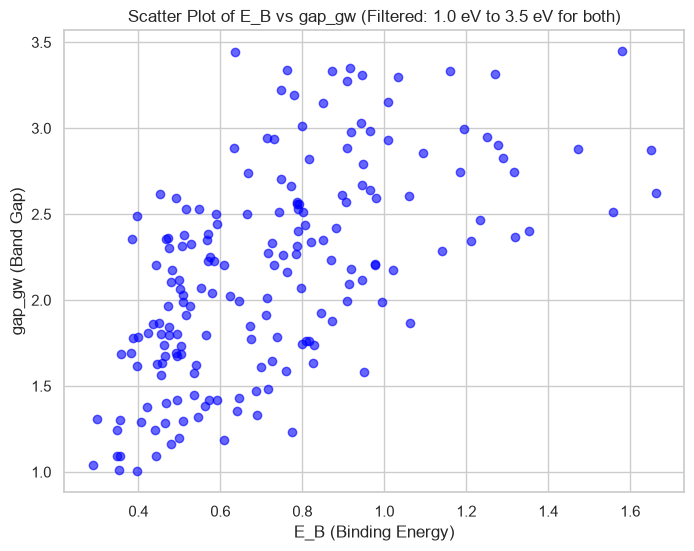

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(
    temp1['E_B'], 
    temp1['gap_gw'], 
    alpha=0.6, 
    color='blue'
)   

plt.xlabel('E_B (Binding Energy)') # X-axis: 1.0 to 3.5
plt.ylabel('gap_gw (Band Gap)')      # Y-axis: 1.0 to 3.5
plt.title('Scatter Plot of E_B vs gap_gw (Filtered: 1.0 eV to 3.5 eV for both)')


In [69]:
corr = temp1[['E_B', 'gap_gw']].corr(method='spearman')
corr

,E_B,gap_gw
E_B,1.000000,0.625889
gap_gw,0.625889,1.000000


In [70]:
temp1.info()

<class 'pandas.DataFrame'>
Index: 184 entries, 2775 to 13376
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 184 non-null    str    
 1   natoms                  184 non-null    int64  
 2   energy                  184 non-null    float64
 3   number                  184 non-null    int64  
 4   has_inversion_symmetry  184 non-null    int64  
 5   lgnum                   184 non-null    int64  
 6   layergroup              184 non-null    int64  
 7   bravais_type            184 non-null    int64  
 8   thickness               184 non-null    float64
 9   evac                    184 non-null    float64
 10  dipz                    184 non-null    float64
 11  minhessianeig           184 non-null    float64
 12  dyn_stab                184 non-null    int64  
 13  alphax_el               184 non-null    float64
 14  alphay_el               184 non-null    float64
 15  

Text(0, 0.5, 'Count / Frequency')

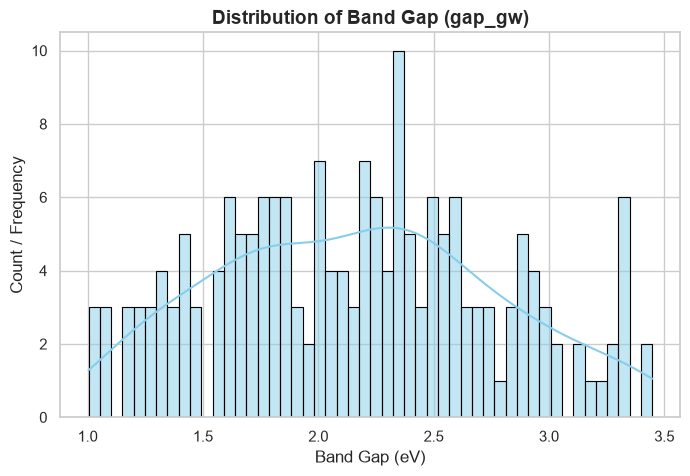

In [71]:
# Set a clean plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Plot histogram with smooth density curve (KDE)
# Seaborn automatically drops NaN values
sns.histplot(temp1['gap_gw'].dropna(), kde=True, bins=50, color='skyblue', edgecolor='black')

plt.title("Distribution of Band Gap (gap_gw)", fontsize=14, fontweight='bold')
plt.xlabel("Band Gap (eV)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)

Text(0, 0.5, 'Count / Frequency')

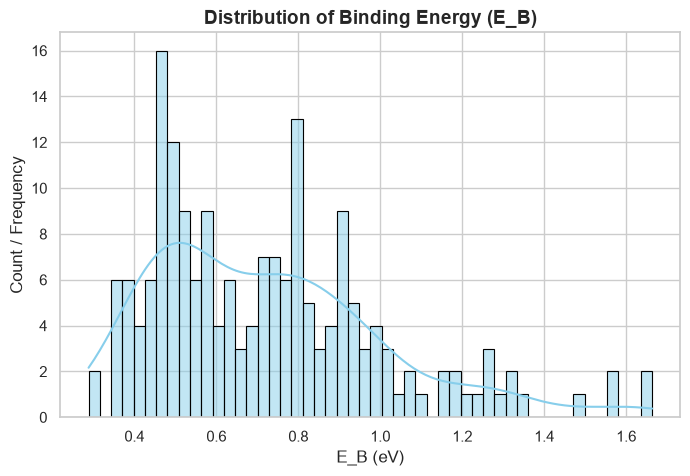

In [72]:
# Set a clean plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

# Plot histogram with smooth density curve (KDE)
# Seaborn automatically drops NaN values
sns.histplot(temp1['E_B'].dropna(), kde=True, bins=50, color='skyblue', edgecolor='black')

plt.title("Distribution of Binding Energy (E_B)", fontsize=14, fontweight='bold')
plt.xlabel("E_B (eV)", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)

In [73]:
outlier_condition = (df_encoded["gap_gw"] < 5.0) & (df_encoded["E_B"] > 2.2)
df_encoded[outlier_condition].info()

<class 'pandas.DataFrame'>
Index: 6 entries, 2995 to 3936
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 6 non-null      str    
 1   natoms                  6 non-null      int64  
 2   energy                  6 non-null      float64
 3   number                  6 non-null      int64  
 4   has_inversion_symmetry  6 non-null      int64  
 5   lgnum                   6 non-null      int64  
 6   layergroup              6 non-null      int64  
 7   bravais_type            6 non-null      int64  
 8   thickness               6 non-null      float64
 9   evac                    6 non-null      float64
 10  dipz                    6 non-null      float64
 11  minhessianeig           6 non-null      float64
 12  dyn_stab                6 non-null      int64  
 13  alphax_el               6 non-null      float64
 14  alphay_el               6 non-null      float64
 15  alp

In [74]:
df_encoded[outlier_condition].head(10)

,formula,natoms,energy,number,has_inversion_symmetry,lgnum,layergroup,bravais_type,thickness,evac,...,topology,plasmafrequency_x,plasmafrequency_y,halfmetal_gap,halfmetal_gap_dir,gap_gw,vbm_gw,cbm_gw,efermi_gw,E_B
2995,VCl2,3,-15.614835,164,1,72,0,0,2.662010,3.054629,...,0,0.0,0.0,NaN,NaN,3.458590,-5.209634,-1.751045,-3.480339,3.826531
3059,NiBr2,3,-11.636157,164,1,72,0,0,2.807625,3.066230,...,0,0.0,0.0,NaN,NaN,2.611186,-6.666633,-4.055447,-5.361040,2.413915
3150,CoBr2,3,-12.412111,164,1,72,0,0,2.868518,3.139562,...,1,0.0,0.0,NaN,NaN,1.400901,-6.252415,-4.851514,-5.551964,2.210593
3605,ScO2,3,-22.190280,187,0,78,1,0,2.070794,2.709802,...,0,0.0,0.0,NaN,NaN,4.420821,-9.130061,-4.709241,-6.919651,3.809866
3809,NiCl2,3,-12.739045,164,1,72,0,0,2.617080,3.093931,...,0,0.0,0.0,NaN,NaN,3.413144,-7.085804,-3.672660,-5.379232,3.349988
3936,VBr2,3,-14.283002,164,1,72,0,0,2.897111,3.061691,...,0,0.0,0.0,NaN,NaN,3.349755,-5.023279,-1.673524,-3.348402,3.292322


In [75]:
df_encoded[~outlier_condition].info()

<class 'pandas.DataFrame'>
Index: 277 entries, 2764 to 13376
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   formula                 277 non-null    str    
 1   natoms                  277 non-null    int64  
 2   energy                  277 non-null    float64
 3   number                  277 non-null    int64  
 4   has_inversion_symmetry  277 non-null    int64  
 5   lgnum                   277 non-null    int64  
 6   layergroup              277 non-null    int64  
 7   bravais_type            277 non-null    int64  
 8   thickness               277 non-null    float64
 9   evac                    277 non-null    float64
 10  dipz                    277 non-null    float64
 11  minhessianeig           277 non-null    float64
 12  dyn_stab                277 non-null    int64  
 13  alphax_el               277 non-null    float64
 14  alphay_el               277 non-null    float64
 15  

In [76]:
corre_03 = df_encoded[["gap_gw", "E_B"]].corr(method='spearman')
corre_03

,gap_gw,E_B
gap_gw,1.000000,0.789473
E_B,0.789473,1.000000


In [77]:
corre_03 = df_encoded[~outlier_condition][["gap_gw", "E_B"]].corr(method='pearson')
corre_03

,gap_gw,E_B
gap_gw,1.000000,0.850938
E_B,0.850938,1.000000


Text(0, 0.5, 'E_B (eV)')

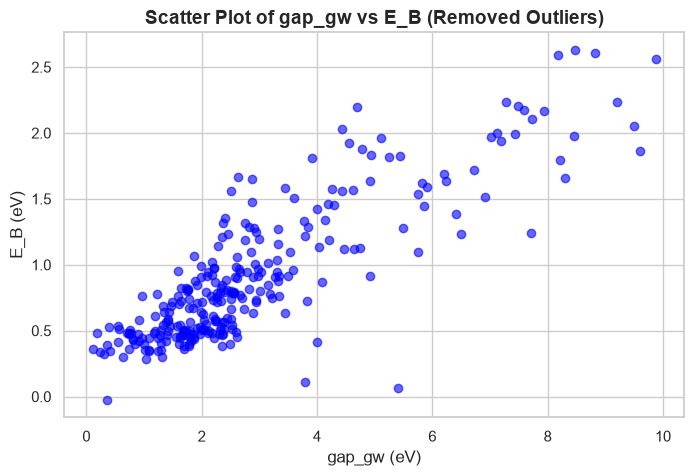

In [78]:
#scatter plot with regression line for the filtered dataset of df_encoded with removed outliers with correlation line with 95% confidence interval


plt.figure(figsize=(8, 5))

plt.scatter(df_encoded[~outlier_condition]["gap_gw"], df_encoded[~outlier_condition]["E_B"], alpha=0.6, color='blue')
plt.title("Scatter Plot of gap_gw vs E_B (Removed Outliers)", fontsize=14, fontweight='bold')
plt.xlabel("gap_gw (eV)", fontsize=12)
plt.ylabel("E_B (eV)", fontsize=12)

In [79]:
temp_03 = df_encoded[~outlier_condition]

In [80]:
between_data  = temp_03[temp_03['gap_gw'].between(1.5, 2.5)]

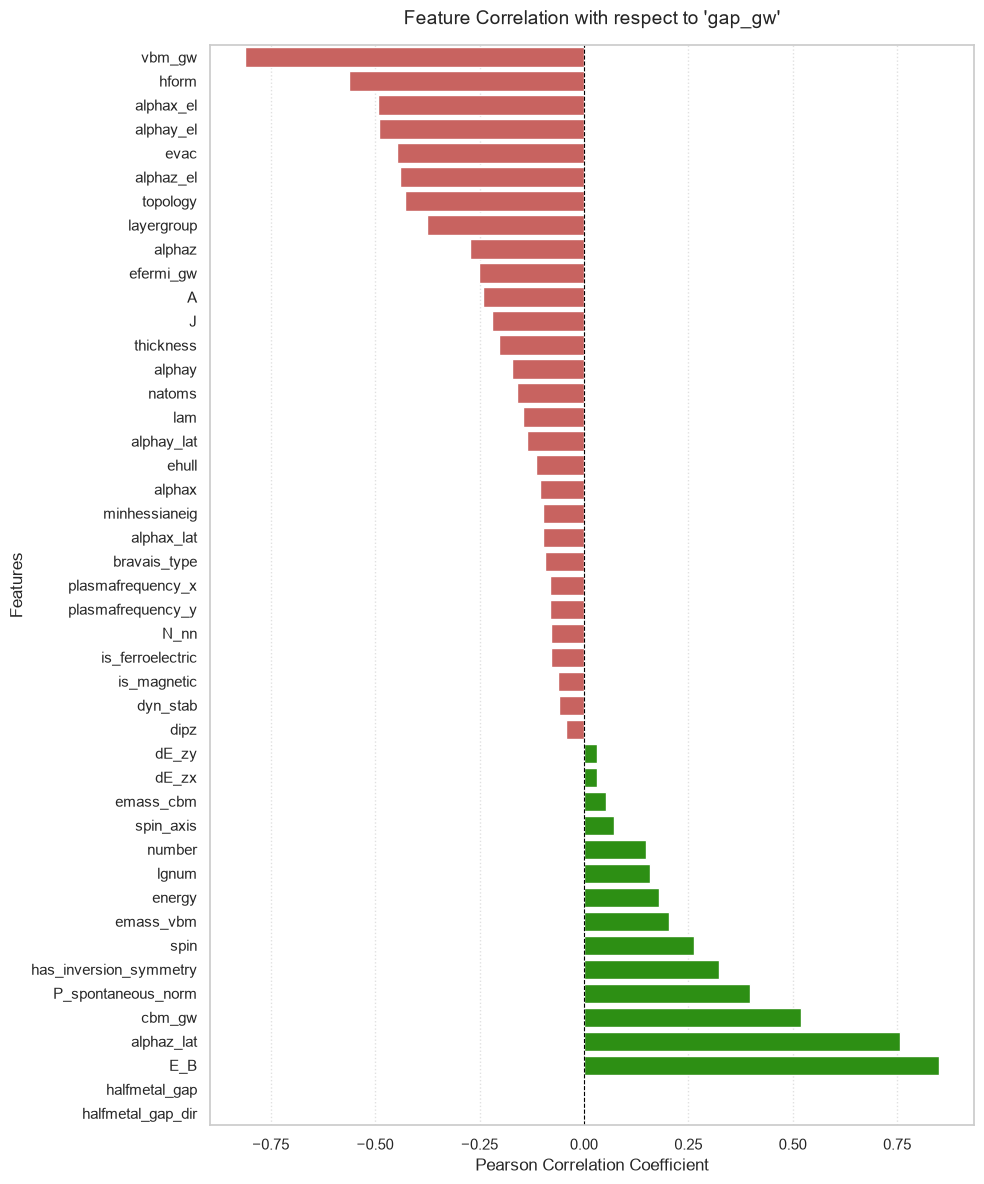

In [81]:
# 1. Compute Pearson correlation with respect to 'gap_gw'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = temp_03.corr(numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw'", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

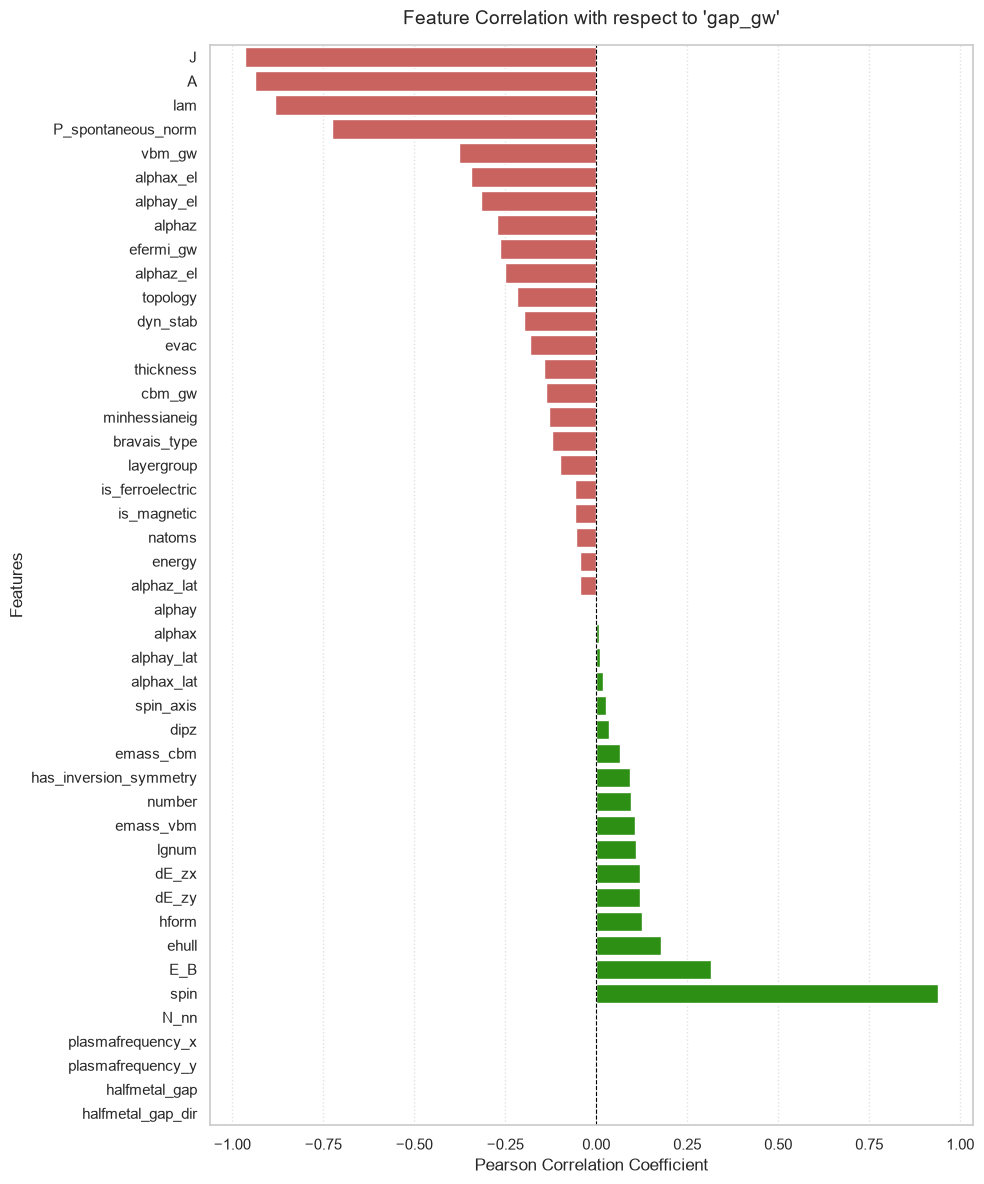

In [82]:
# 1. Compute Pearson correlation with respect to 'gap_gw'
# (numeric_only=True automatically ignores string columns like 'formula')
correlations = between_data.corr(numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw'", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [83]:
corre_03 = temp_03.drop(columns=['formula']).corr(method='pearson')

In [84]:
corre_03

,natoms,energy,number,has_inversion_symmetry,lgnum,layergroup,bravais_type,thickness,evac,dipz,...,topology,plasmafrequency_x,plasmafrequency_y,halfmetal_gap,halfmetal_gap_dir,gap_gw,vbm_gw,cbm_gw,efermi_gw,E_B
natoms,1.000000,-0.438066,-0.326759,0.094924,-0.319366,0.120460,0.470718,0.611137,0.251377,0.039176,...,0.192241,0.111184,0.111184,NaN,NaN,-0.160292,0.173400,-0.019731,0.098006,-0.140354
energy,-0.438066,1.000000,0.012350,0.025843,0.015774,0.057001,-0.074450,-0.086621,-0.460754,0.185931,...,-0.163881,-0.173388,-0.173388,NaN,NaN,0.180906,-0.178188,0.047877,-0.087224,0.100656
number,-0.326759,0.012350,1.000000,-0.164770,0.993243,-0.624933,-0.659661,0.223557,0.190882,-0.040648,...,0.017414,0.043683,0.043683,NaN,NaN,0.148810,-0.185276,-0.017214,-0.132515,0.172951
has_inversion_symmetry,0.094924,0.025843,-0.164770,1.000000,-0.130620,-0.485758,0.203072,-0.244664,-0.352413,-0.116940,...,-0.124586,-0.037685,-0.037685,NaN,NaN,0.322290,-0.251134,0.182275,-0.102017,0.256771
lgnum,-0.319366,0.015774,0.993243,-0.130620,1.000000,-0.606566,-0.624641,0.217995,0.187426,-0.041317,...,0.005031,0.040884,0.040884,NaN,NaN,0.159266,-0.187996,-0.003362,-0.127882,0.174037
layergroup,0.120460,0.057001,-0.624933,-0.485758,-0.606566,1.000000,0.493241,-0.014262,0.088014,0.182480,...,0.038692,-0.026036,-0.026036,NaN,NaN,-0.376772,0.340258,-0.144835,0.167277,-0.374554
bravais_type,0.470718,-0.074450,-0.659661,0.203072,-0.624641,0.493241,1.000000,-0.110609,-0.114492,-0.047649,...,-0.001266,-0.015339,-0.015339,NaN,NaN,-0.092525,0.180094,0.105605,0.183956,-0.070754
thickness,0.611137,-0.086621,0.223557,-0.244664,0.217995,-0.014262,-0.110609,1.000000,0.546945,0.197918,...,0.207388,0.096730,0.096730,NaN,NaN,-0.202189,0.166372,-0.101447,0.067682,-0.211570
evac,0.251377,-0.460754,0.190882,-0.352413,0.187426,0.088014,-0.114492,0.546945,1.000000,-0.027057,...,0.204816,0.178081,0.178081,NaN,NaN,-0.447892,0.418373,-0.151868,0.196540,-0.366941
dipz,0.039176,0.185931,-0.040648,-0.116940,-0.041317,0.182480,-0.047649,0.197918,-0.027057,1.000000,...,-0.004355,-0.011244,-0.011244,NaN,NaN,-0.042689,-0.124143,-0.254333,-0.221968,-0.054394


In [85]:
df_encoded.to_csv("df_encoded_final.csv", index=False)

In [86]:
import re

df_encoded["num_elements"] = df_encoded["formula"].apply(
    lambda x: len(set(re.findall(r'[A-Z][a-z]?', x)))
)

In [87]:
df_encoded["num_elements"].head()

2764    2
2765    2
2775    2
2782    2
2800    2
Name: num_elements, dtype: int64

In [88]:
df_encoded.to_csv("df_encoded_final.csv", index=False)

# Improvements - 05/08/2026

In [89]:
data = df_encoded.copy()

In [90]:
df_encoded['num_elements'].unique()

array([2, 3, 1])

In [91]:
df_binary = data[data['num_elements'] == 2].copy()
df_trinary = data[data['num_elements'] == 3].copy()
df_homonuclear = data[data['num_elements'] == 1].copy()

In [92]:
len(df_binary)

201

In [93]:
len(df_trinary)

80

In [94]:
len(df_encoded)

283

In [95]:
len(df_homonuclear)

2

In [96]:
corre_04 = df_binary[["gap_gw", "E_B"]].corr(method='pearson')
corre_04

,gap_gw,E_B
gap_gw,1.000000,0.704663
E_B,0.704663,1.000000


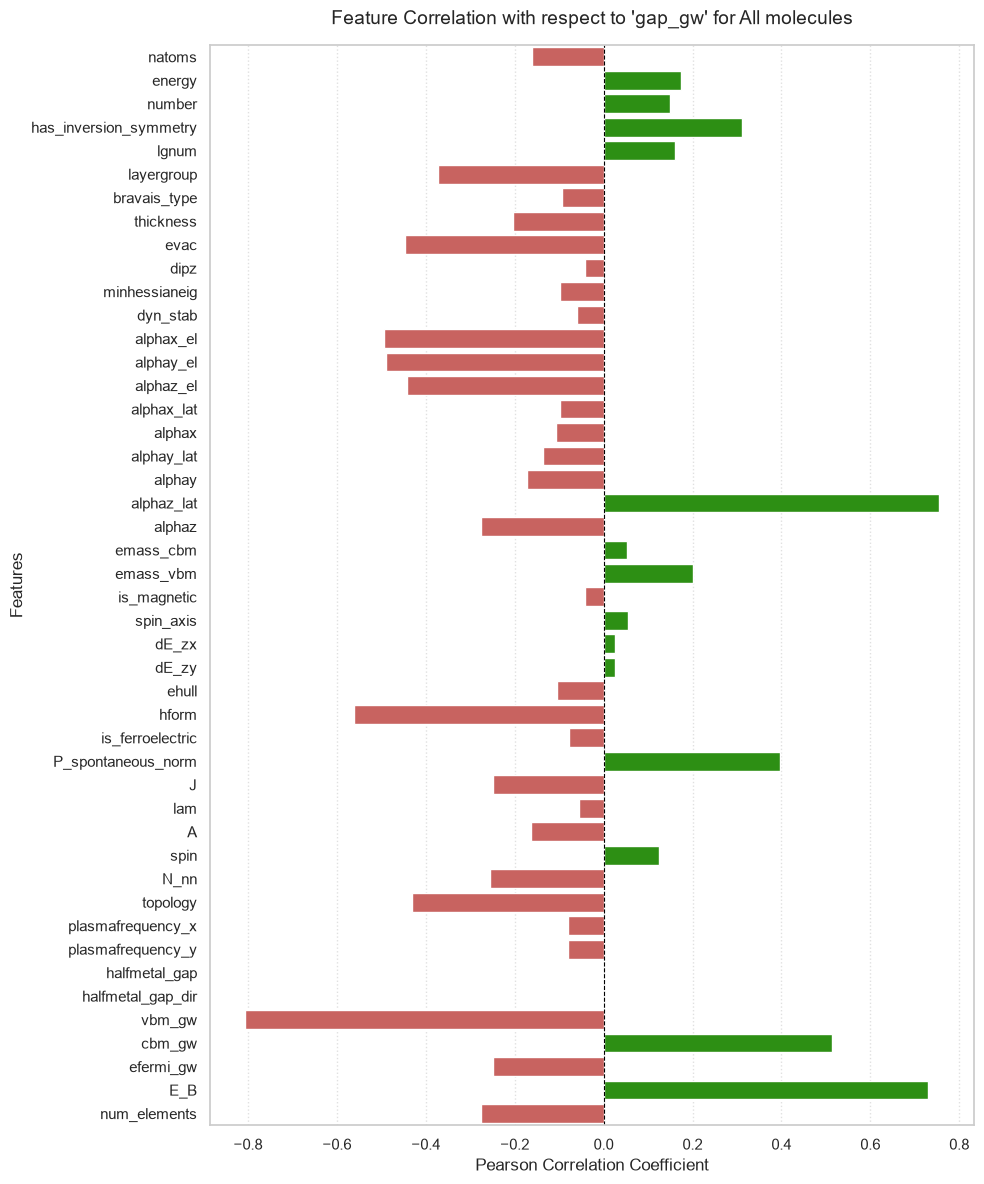

In [97]:

correlations = df_encoded.corr(numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations #.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw' for All molecules", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

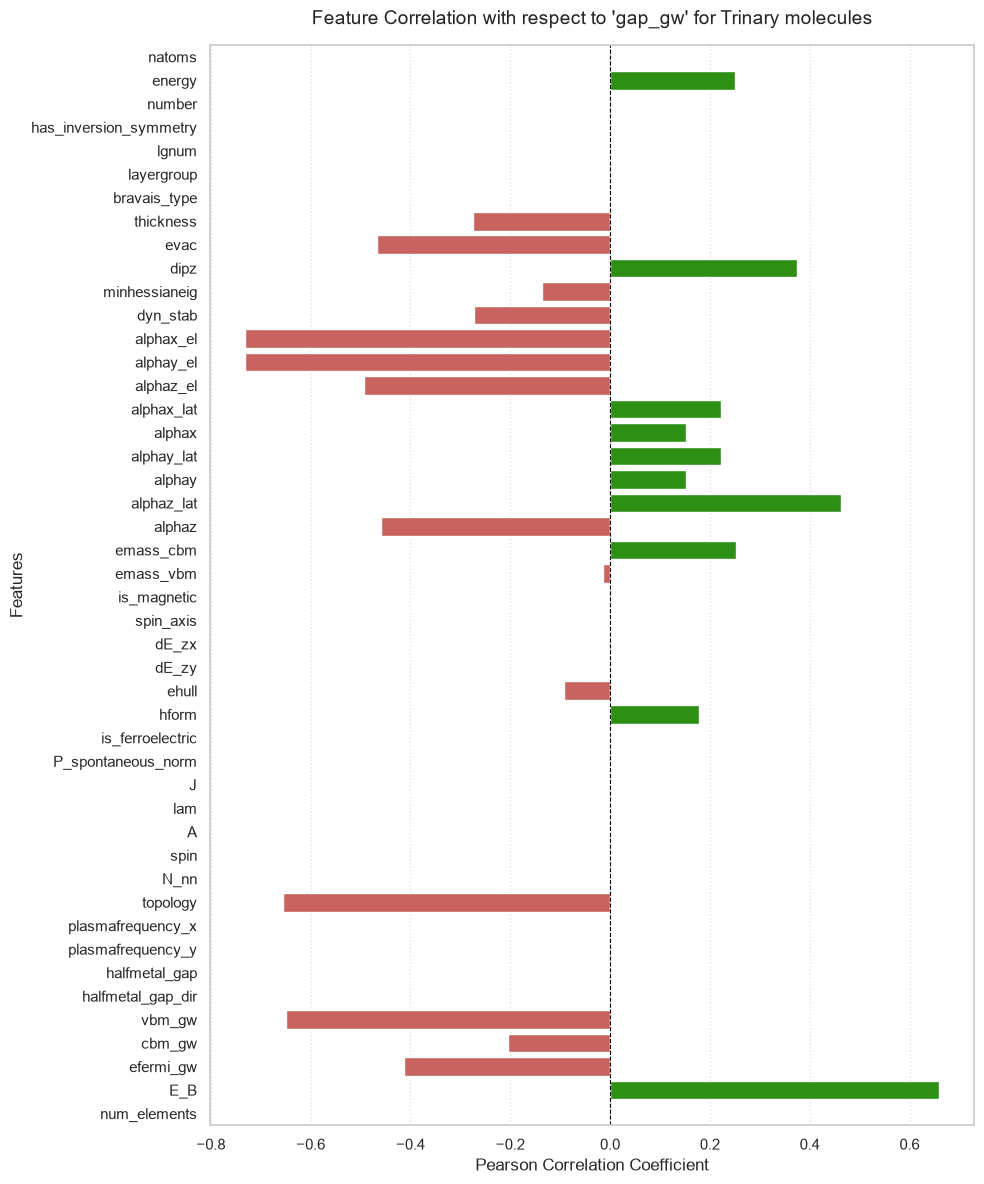

In [98]:

correlations = df_trinary.corr(numeric_only=True)['gap_gw'].drop('gap_gw')


# 2. Sort correlations in ascending order for clean plotting
correlations_sorted = correlations #.sort_values()

# 3. Create the correlation bar chart
plt.figure(figsize=(10, 12))
colors = ['#d9534f' if val < 0 else "#21a300" for val in correlations_sorted]

ax = sns.barplot(
    x=correlations_sorted.values, 
    y=correlations_sorted.index, 
    palette=colors,
    hue=correlations_sorted.index,
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title("Feature Correlation with respect to 'gap_gw' for Trinary molecules", fontsize=14, pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [99]:
elements = df_encoded["formula"].apply(
    lambda x: re.findall(r'[A-Z][a-z]?', x)
)

max_elements = elements.str.len().max()

df_elements = pd.DataFrame(
    elements.tolist(),
    columns=[f"element_{i+1}" for i in range(max_elements)],
    index=df_encoded.index
)

df_encoded = pd.concat([df_encoded, df_elements], axis=1)

In [100]:
df_encoded.columns

Index(['formula', 'natoms', 'energy', 'number', 'has_inversion_symmetry',
       'lgnum', 'layergroup', 'bravais_type', 'thickness', 'evac', 'dipz',
       'minhessianeig', 'dyn_stab', 'alphax_el', 'alphay_el', 'alphaz_el',
       'alphax_lat', 'alphax', 'alphay_lat', 'alphay', 'alphaz_lat', 'alphaz',
       'emass_cbm', 'emass_vbm', 'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy',
       'ehull', 'hform', 'is_ferroelectric', 'P_spontaneous_norm', 'J', 'lam',
       'A', 'spin', 'N_nn', 'topology', 'plasmafrequency_x',
       'plasmafrequency_y', 'halfmetal_gap', 'halfmetal_gap_dir', 'gap_gw',
       'vbm_gw', 'cbm_gw', 'efermi_gw', 'E_B', 'num_elements', 'element_1',
       'element_2', 'element_3'],
      dtype='str')

In [101]:
df_encoded[["element_1", "element_2", "element_3", "num_elements"]].head()

,element_1,element_2,element_3,num_elements
2764,Mg,Cl,NaN,2
2765,Mg,Cl,NaN,2
2775,Ru,Br,NaN,2
2782,Mn,Cl,NaN,2
2800,W,Te,NaN,2


In [102]:
df_encoded.to_csv("df_encoded_final.csv", index=False)

In [103]:
elements = ["element_1", "element_2", "element_3"]

df_encoded["elements"] = df_encoded[elements].apply(
    lambda x: [e for e in x if pd.notna(e)], axis=1
)

In [104]:
df_encoded.columns

Index(['formula', 'natoms', 'energy', 'number', 'has_inversion_symmetry',
       'lgnum', 'layergroup', 'bravais_type', 'thickness', 'evac', 'dipz',
       'minhessianeig', 'dyn_stab', 'alphax_el', 'alphay_el', 'alphaz_el',
       'alphax_lat', 'alphax', 'alphay_lat', 'alphay', 'alphaz_lat', 'alphaz',
       'emass_cbm', 'emass_vbm', 'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy',
       'ehull', 'hform', 'is_ferroelectric', 'P_spontaneous_norm', 'J', 'lam',
       'A', 'spin', 'N_nn', 'topology', 'plasmafrequency_x',
       'plasmafrequency_y', 'halfmetal_gap', 'halfmetal_gap_dir', 'gap_gw',
       'vbm_gw', 'cbm_gw', 'efermi_gw', 'E_B', 'num_elements', 'element_1',
       'element_2', 'element_3', 'elements'],
      dtype='str')

In [105]:
df_encoded["elements"].head()

2764    [Mg, Cl]
2765    [Mg, Cl]
2775    [Ru, Br]
2782    [Mn, Cl]
2800     [W, Te]
Name: elements, dtype: object

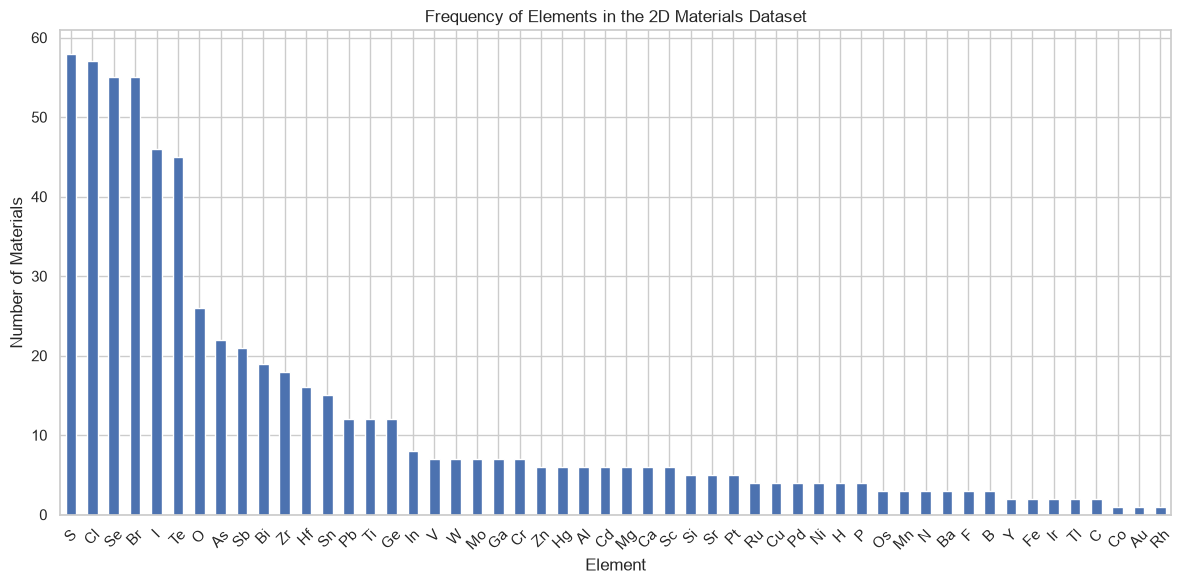

In [106]:
from collections import Counter
element_counter = Counter(
    element
    for elements in df_encoded["elements"]
    for element in set(elements)
)

element_frequency = (
    pd.Series(element_counter)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

element_frequency.plot(
    kind="bar"
)

plt.xlabel("Element")
plt.ylabel("Number of Materials")
plt.title("Frequency of Elements in the 2D Materials Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [107]:
property_cols = [
    "gap_gw",
    "E_B",
    "ehull",
    "hform",
    "thickness",
    "emass_cbm",
    "emass_vbm",
    "alphax",
    "alphay",
    "alphaz"
]

In [108]:
property_cols = [
    col for col in property_cols
    if col in df_encoded.columns
]

print(property_cols)

['gap_gw', 'E_B', 'ehull', 'hform', 'thickness', 'emass_cbm', 'emass_vbm', 'alphax', 'alphay', 'alphaz']


In [109]:
element_property_data = []

for element in element_frequency.index:

    mask = df_encoded["elements"].apply(
        lambda x: element in x
    )

    subset = df_encoded.loc[mask]

    values = {
        "element": element
    }

    for prop in property_cols:
        values[prop] = subset[prop].median()

    element_property_data.append(values)

element_property_df = pd.DataFrame(
    element_property_data
)

element_property_df = element_property_df.set_index("element")

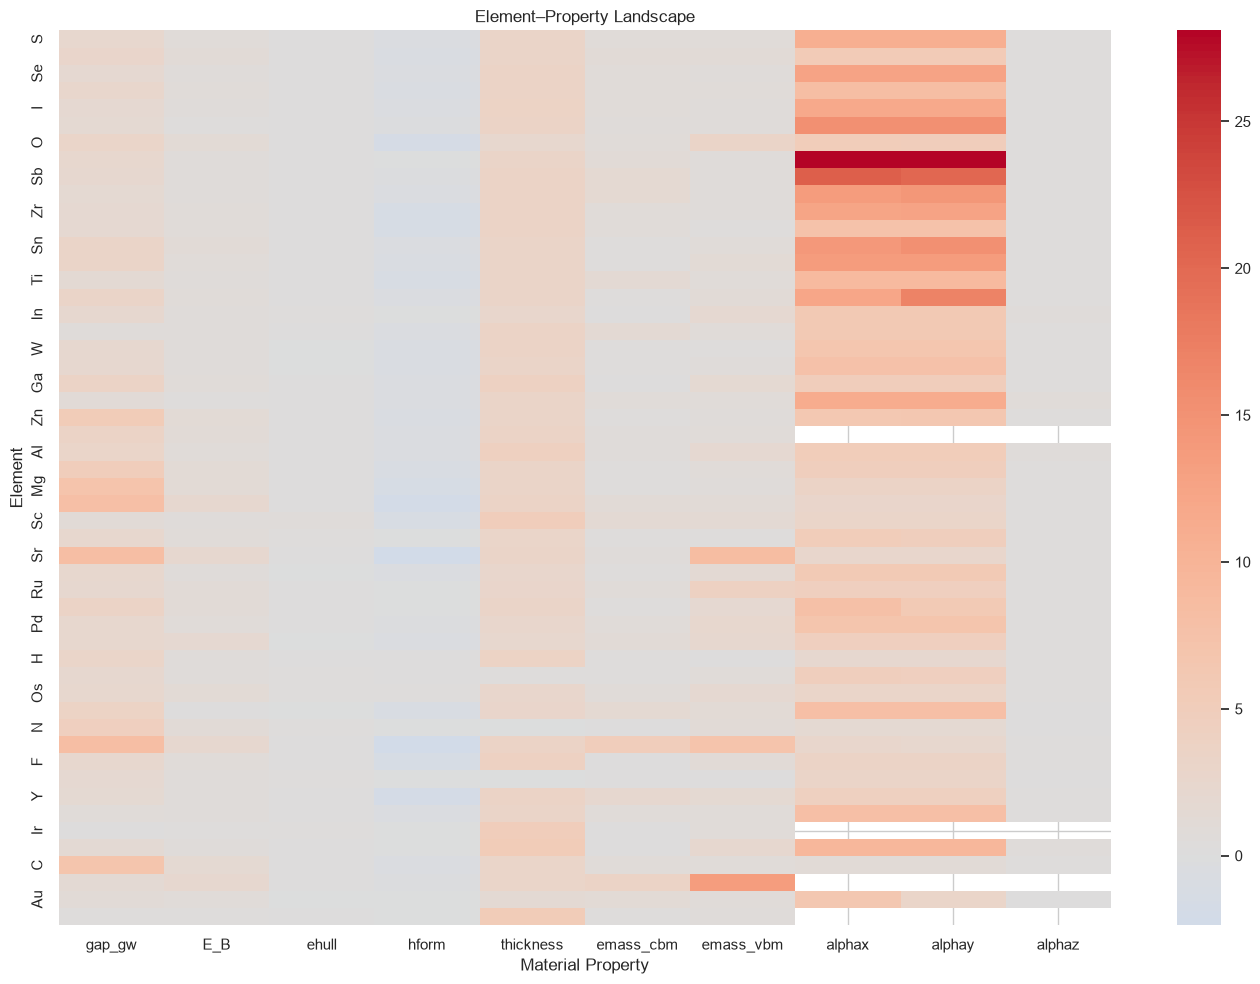

In [110]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    element_property_df,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Element–Property Landscape")
plt.xlabel("Material Property")
plt.ylabel("Element")
plt.tight_layout()
plt.show()

In [111]:
min_materials = 10

common_elements = [
    element
    for element, count in element_frequency.items()
    if count >= min_materials
]

print([(common_element, int(element_frequency[common_element])) for common_element in common_elements])

[('S', 58), ('Cl', 57), ('Se', 55), ('Br', 55), ('I', 46), ('Te', 45), ('O', 26), ('As', 22), ('Sb', 21), ('Bi', 19), ('Zr', 18), ('Hf', 16), ('Sn', 15), ('Pb', 12), ('Ti', 12), ('Ge', 12)]


In [112]:
df_binary = df_encoded[df_encoded['num_elements'] == 2].copy()

## ViolinePlot for Band Gap 

In [113]:
gap_data = []

for element in common_elements:

    mask = df_encoded["elements"].apply(
        lambda x: element in x
    )

    temp = df_encoded.loc[mask, ["gap_gw"]].copy()

    temp["element"] = element

    gap_data.append(temp)

gap_data = pd.concat(gap_data, ignore_index=True)

gap_data = gap_data.dropna(subset=["gap_gw"])

In [114]:
gap_data.head()

,gap_gw,element
0,2.826492,S
1,2.937988,S
2,1.762762,S
3,2.265981,S
4,2.532907,S


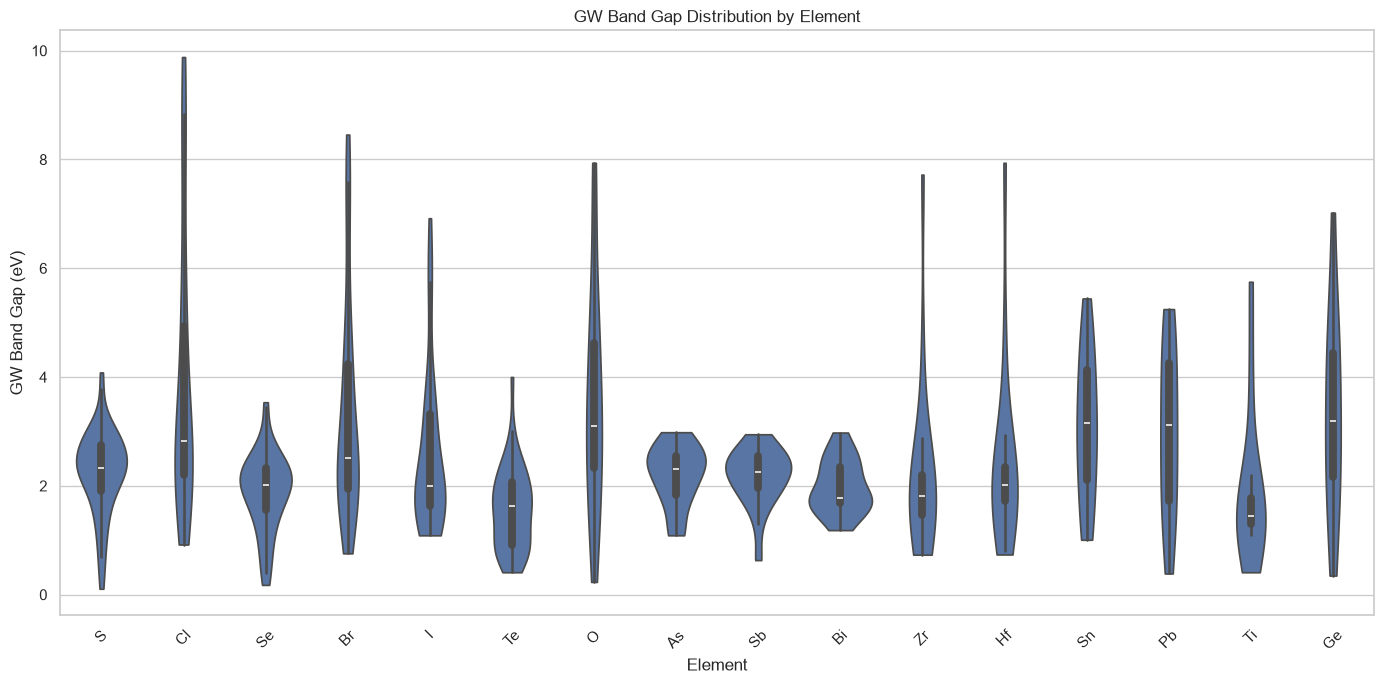

In [115]:
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=gap_data,
    x="element",
    y="gap_gw",
    inner="box",
    cut=0
)

plt.xlabel("Element")
plt.ylabel("GW Band Gap (eV)")
plt.title("GW Band Gap Distribution by Element")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

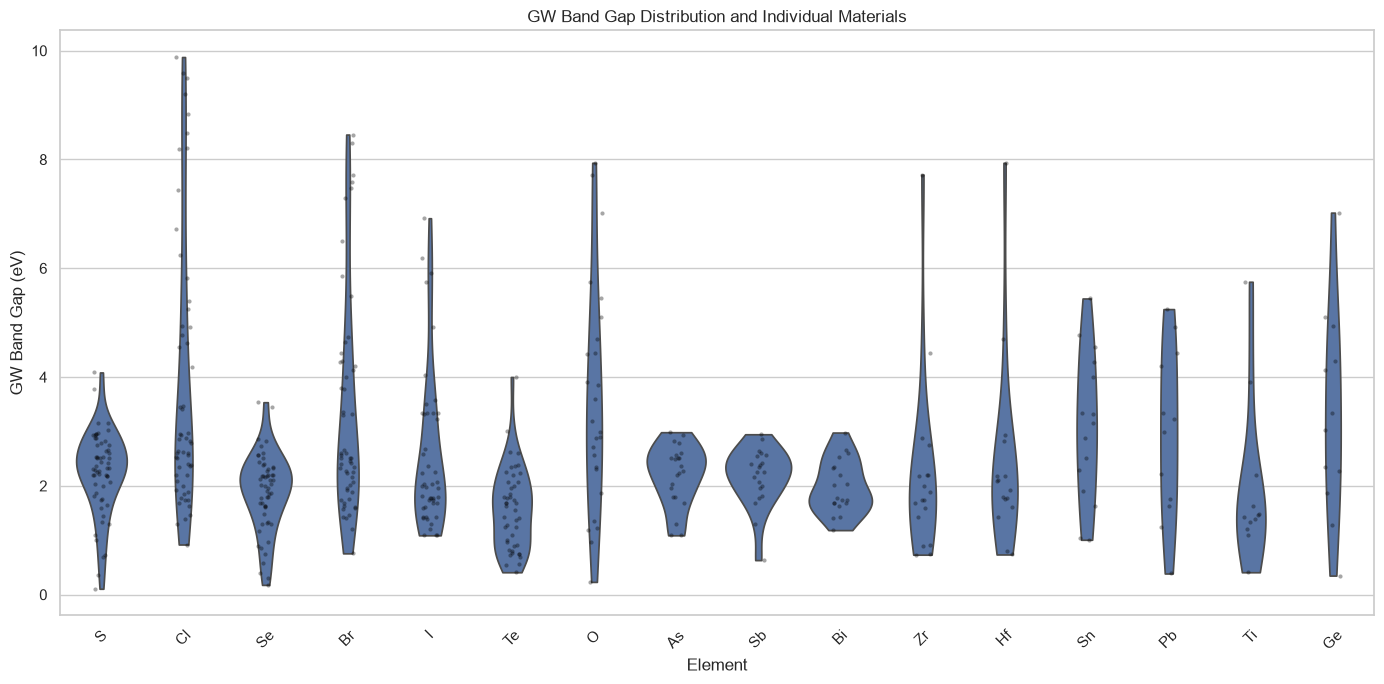

In [116]:
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=gap_data,
    x="element",
    y="gap_gw",
    inner=None,
    cut=0
)

sns.stripplot(
    data=gap_data,
    x="element",
    y="gap_gw",
    color="black",
    alpha=0.35,
    size=3,
    jitter=True
)

plt.xlabel("Element")
plt.ylabel("GW Band Gap (eV)")
plt.title("GW Band Gap Distribution and Individual Materials")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ViolinePlot for Binding Energy

In [117]:
gap_data = []

for element in common_elements:

    mask = df_encoded["elements"].apply(
        lambda x: element in x
    )

    temp = df_encoded.loc[mask, ["E_B"]].copy()

    temp["element"] = element

    gap_data.append(temp)

gap_data = pd.concat(gap_data, ignore_index=True)

gap_data = gap_data.dropna(subset=["E_B"])

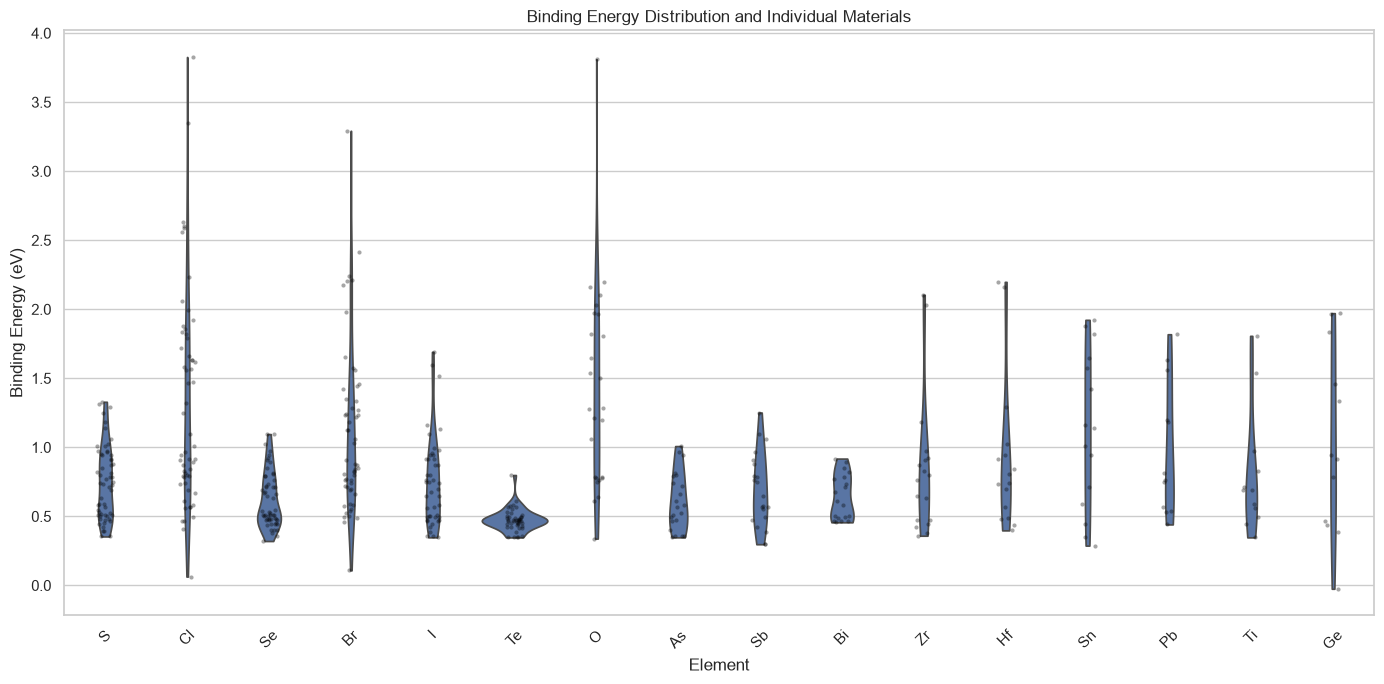

In [118]:
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=gap_data,
    x="element",
    y="E_B",
    inner=None,
    cut=0
)

sns.stripplot(
    data=gap_data,
    x="element",
    y="E_B",
    color="black",
    alpha=0.35,
    size=3,
    jitter=True
)

plt.xlabel("Element")
plt.ylabel("Binding Energy (eV)")
plt.title("Binding Energy Distribution and Individual Materials")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Relations between the Pairs with the Band Gap

### For Complete Data Set (df_encoded)

In [119]:
import itertools
pair_rows = []

for idx, row in df_encoded.iterrows():

    elements = row["elements"]

    unique_elements = sorted(set(elements))

    for e1, e2 in itertools.combinations(unique_elements, 2):

        pair_rows.append({
            "material_index": idx,
            "element_pair": f"{e1}-{e2}"
        })

pair_df = pd.DataFrame(pair_rows)

print("Pair dataframe shape:", pair_df.shape)
print(pair_df.head())

Pair dataframe shape: (441, 2)
   material_index element_pair
0            2764        Cl-Mg
1            2765        Cl-Mg
2            2775        Br-Ru
3            2782        Cl-Mn
4            2800         Te-W


In [120]:
pair_df = pair_df.merge(
    df_encoded[["gap_gw"]],
    left_on="material_index",
    right_index=True,
    how="left"
)

print(pair_df.head())
print(pair_df["gap_gw"].notna().sum())

   material_index element_pair    gap_gw
0            2764        Cl-Mg  9.598559
1            2765        Cl-Mg  8.209944
2            2775        Br-Ru  2.403058
3            2782        Cl-Mn  5.398439
4            2800         Te-W  1.376623
441


In [121]:
pair_df = pair_df.dropna(subset=["gap_gw"])

print("After removing NaN:", pair_df.shape)

After removing NaN: (441, 3)


In [122]:
pair_counts = pair_df["element_pair"].value_counts()

common_pairs = pair_counts[
    pair_counts >= 5
].index

pair_gap_data = pair_df[
    pair_df["element_pair"].isin(common_pairs)
]

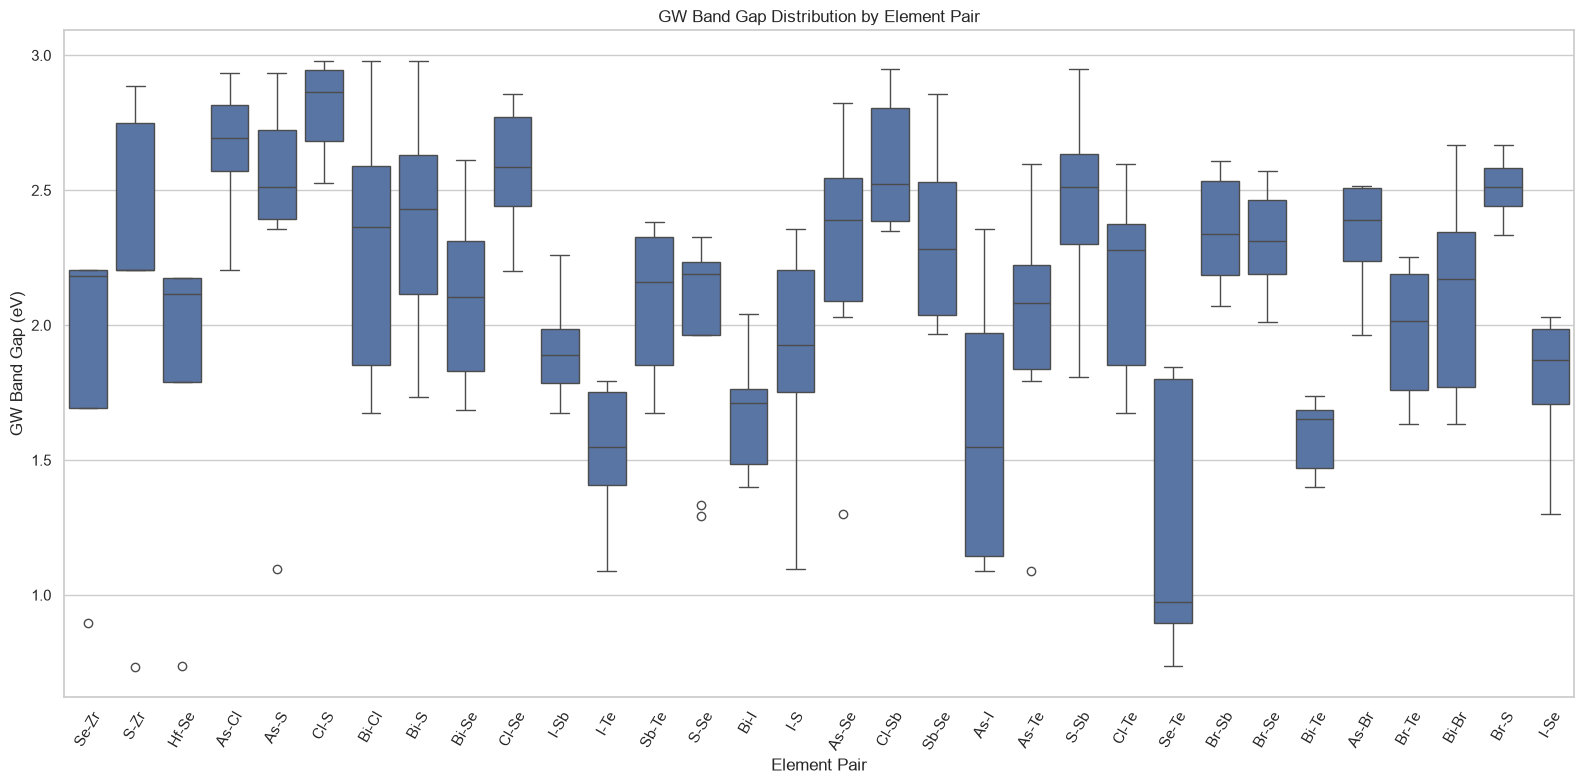

In [123]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=pair_gap_data,
    x="element_pair",
    y="gap_gw"
)

plt.xlabel("Element Pair")
plt.ylabel("GW Band Gap (eV)")
plt.title("GW Band Gap Distribution by Element Pair")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [124]:
pair_stats = (
    pair_df
    .groupby("element_pair")["gap_gw"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

# Calculate range
pair_stats["range"] = (
    pair_stats["max"] - pair_stats["min"]
)

# Calculate IQR
q1 = (
    pair_df
    .groupby("element_pair")["gap_gw"]
    .quantile(0.25)
)

q3 = (
    pair_df
    .groupby("element_pair")["gap_gw"]
    .quantile(0.75)
)

pair_stats["Q1"] = pair_stats["element_pair"].map(q1)
pair_stats["Q3"] = pair_stats["element_pair"].map(q3)

pair_stats["IQR"] = (
    pair_stats["Q3"] - pair_stats["Q1"]
)

pair_stats.head()

,element_pair,count,mean,median,std,min,max,range,Q1,Q3,IQR
0,Al-As,1,2.985676,2.985676,NaN,2.985676,2.985676,0.0,2.985676,2.985676,0.0
1,Al-O,1,2.568456,2.568456,NaN,2.568456,2.568456,0.0,2.568456,2.568456,0.0
2,Al-S,1,3.774278,3.774278,NaN,3.774278,3.774278,0.0,3.774278,3.774278,0.0
3,Al-Sb,1,2.557698,2.557698,NaN,2.557698,2.557698,0.0,2.557698,2.557698,0.0
4,Al-Se,1,3.537264,3.537264,NaN,3.537264,3.537264,0.0,3.537264,3.537264,0.0


In [125]:
pair_stats.to_csv("pair_state_gap_gw.csv")

In [126]:
pair_rows = []

for idx, row in df_encoded.iterrows():

    elements = sorted(set(row["elements"]))

    for e1, e2 in itertools.combinations(elements, 2):

        pair_rows.append({
            "material_index": idx,
            "element_pair": f"{e1}-{e2}",
            "gap_gw": row["gap_gw"],
            "E_B": row["E_B"],
            "hform": row["hform"],
            "ehull": row["ehull"]
        })

pair_df = pd.DataFrame(pair_rows)

In [127]:
pair_df_EB = pair_df.copy()

pair_df_EB = pair_df_EB.dropna(subset=["E_B"])

common_pairs_EB = (
    pair_df_EB["element_pair"]
    .value_counts()
)

common_pairs_EB = common_pairs_EB[
    common_pairs_EB >= 5
].index

pair_EB_data = pair_df_EB[
    pair_df_EB["element_pair"].isin(common_pairs_EB)
]

print(pair_EB_data.head())
print(pair_EB_data.shape)

     material_index element_pair    gap_gw       E_B     hform     ehull
88             3779        Se-Zr  1.691201  0.381305 -1.367250  0.000000
89             3780        Se-Zr  2.182698  0.919398 -1.223209  0.144041
113            4109         S-Zr  2.748124  1.184209 -1.395686  0.189806
114            4111         S-Zr  2.885060  0.633273 -1.585491  0.000000
120            4145        Hf-Se  1.787573  0.398518 -1.349050  0.000000
(190, 6)


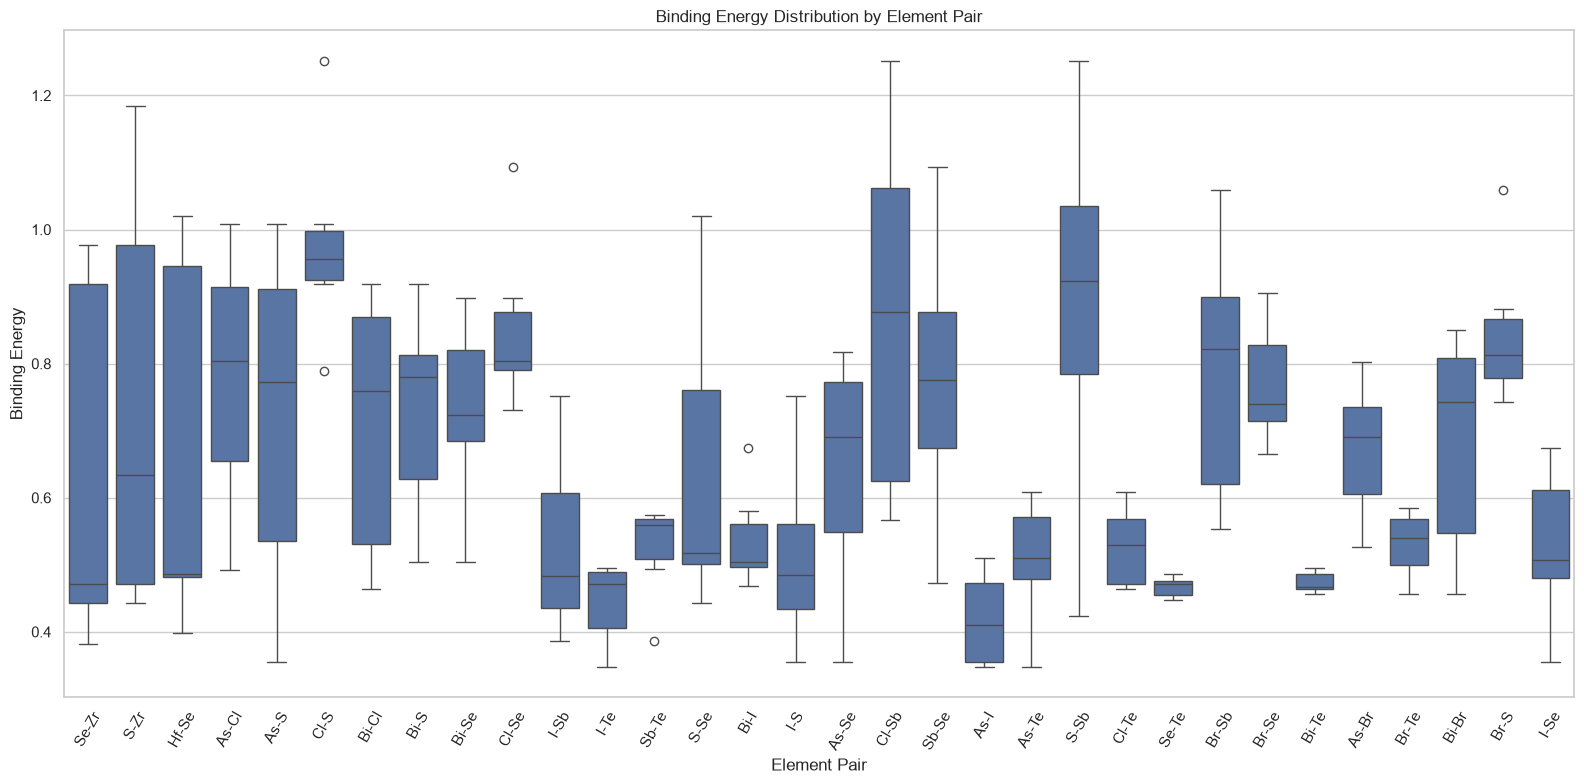

In [128]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=pair_EB_data,
    x="element_pair",
    y="E_B"
)

plt.xlabel("Element Pair")
plt.ylabel("Binding Energy")
plt.title("Binding Energy Distribution by Element Pair")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [129]:
pair_stats_eb = (
    pair_EB_data
    .groupby("element_pair")["E_B"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

# Calculate range
pair_stats_eb["range"] = (
    pair_stats_eb["max"] - pair_stats_eb["min"]
)

# Calculate IQR
q1 = (
    pair_EB_data
    .groupby("element_pair")["E_B"]
    .quantile(0.25)
)

q3 = (
    pair_EB_data
    .groupby("element_pair")["E_B"]
    .quantile(0.75)
)

pair_stats_eb["Q1"] = pair_stats_eb["element_pair"].map(q1)
pair_stats_eb["Q3"] = pair_stats_eb["element_pair"].map(q3)

pair_stats_eb["IQR"] = (
    pair_stats_eb["Q3"] - pair_stats_eb["Q1"]
)

pair_stats_eb.head()

,element_pair,count,mean,median,std,min,max,range,Q1,Q3,IQR
0,As-Br,6,0.673145,0.690846,0.102624,0.526896,0.802747,0.275850,0.605177,0.735896,0.130719
1,As-Cl,6,0.777413,0.804030,0.197067,0.491856,1.008792,0.516937,0.654123,0.914719,0.260597
2,As-I,6,0.418016,0.410399,0.073369,0.348056,0.509777,0.161721,0.354560,0.472739,0.118180
3,As-S,6,0.720278,0.772516,0.260913,0.354525,1.008792,0.654267,0.535172,0.911077,0.375905
4,As-Se,6,0.642366,0.690846,0.178335,0.354664,0.817318,0.462654,0.548574,0.772238,0.223664


In [130]:
pair_stats_eb.to_csv("pair_stats_eb.csv")

In [131]:
# Keep the first occurrence of each column name and drop duplicates
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()]

In [132]:
df_encoded.columns

Index(['formula', 'natoms', 'energy', 'number', 'has_inversion_symmetry',
       'lgnum', 'layergroup', 'bravais_type', 'thickness', 'evac', 'dipz',
       'minhessianeig', 'dyn_stab', 'alphax_el', 'alphay_el', 'alphaz_el',
       'alphax_lat', 'alphax', 'alphay_lat', 'alphay', 'alphaz_lat', 'alphaz',
       'emass_cbm', 'emass_vbm', 'is_magnetic', 'spin_axis', 'dE_zx', 'dE_zy',
       'ehull', 'hform', 'is_ferroelectric', 'P_spontaneous_norm', 'J', 'lam',
       'A', 'spin', 'N_nn', 'topology', 'plasmafrequency_x',
       'plasmafrequency_y', 'halfmetal_gap', 'halfmetal_gap_dir', 'gap_gw',
       'vbm_gw', 'cbm_gw', 'efermi_gw', 'E_B', 'num_elements', 'element_1',
       'element_2', 'element_3', 'elements'],
      dtype='str')

In [133]:
df_encoded[['formula','num_elements']]

,formula,num_elements
2764,MgCl2,2
2765,MgCl2,2
2775,RuBr2,2
2782,MnCl2,2
2800,WTe2,2
...,...,...
10567,In2O2,2
10576,F2Ge2,2
10577,Ge2S2,2
13375,P4,1


### For Binary Data 

In [143]:
import itertools
pair_rows = []

for idx, row in df_binary.iterrows():

    elements = row["elements"]

    unique_elements = sorted(set(elements))

    for e1, e2 in itertools.combinations(unique_elements, 2):

        pair_rows.append({
            "material_index": idx,
            "element_pair": f"{e1}-{e2}"
        })

pair_df = pd.DataFrame(pair_rows)

print("Pair dataframe shape:", pair_df.shape)
print(pair_df.head())

Pair dataframe shape: (201, 2)
   material_index element_pair
0            2764        Cl-Mg
1            2765        Cl-Mg
2            2775        Br-Ru
3            2782        Cl-Mn
4            2800         Te-W


In [144]:
pair_df = pair_df.merge(
    df_binary[["gap_gw"]],
    left_on="material_index",
    right_index=True,
    how="left"
)

In [157]:
print(pair_df.head())
print(pair_df["gap_gw"].notna().sum())
pair_df = pair_df.dropna(subset=["gap_gw"])

print("After removing NaN:", pair_df.shape)
pair_counts = pair_df["element_pair"].value_counts()

common_pairs = pair_counts[
    pair_counts >= 2
].index

pair_gap_data = pair_df[
    pair_df["element_pair"].isin(common_pairs)
]

   material_index element_pair    gap_gw
0            2764        Cl-Mg  9.598559
1            2765        Cl-Mg  8.209944
2            2775        Br-Ru  2.403058
3            2782        Cl-Mn  5.398439
4            2800         Te-W  1.376623
201
After removing NaN: (201, 3)


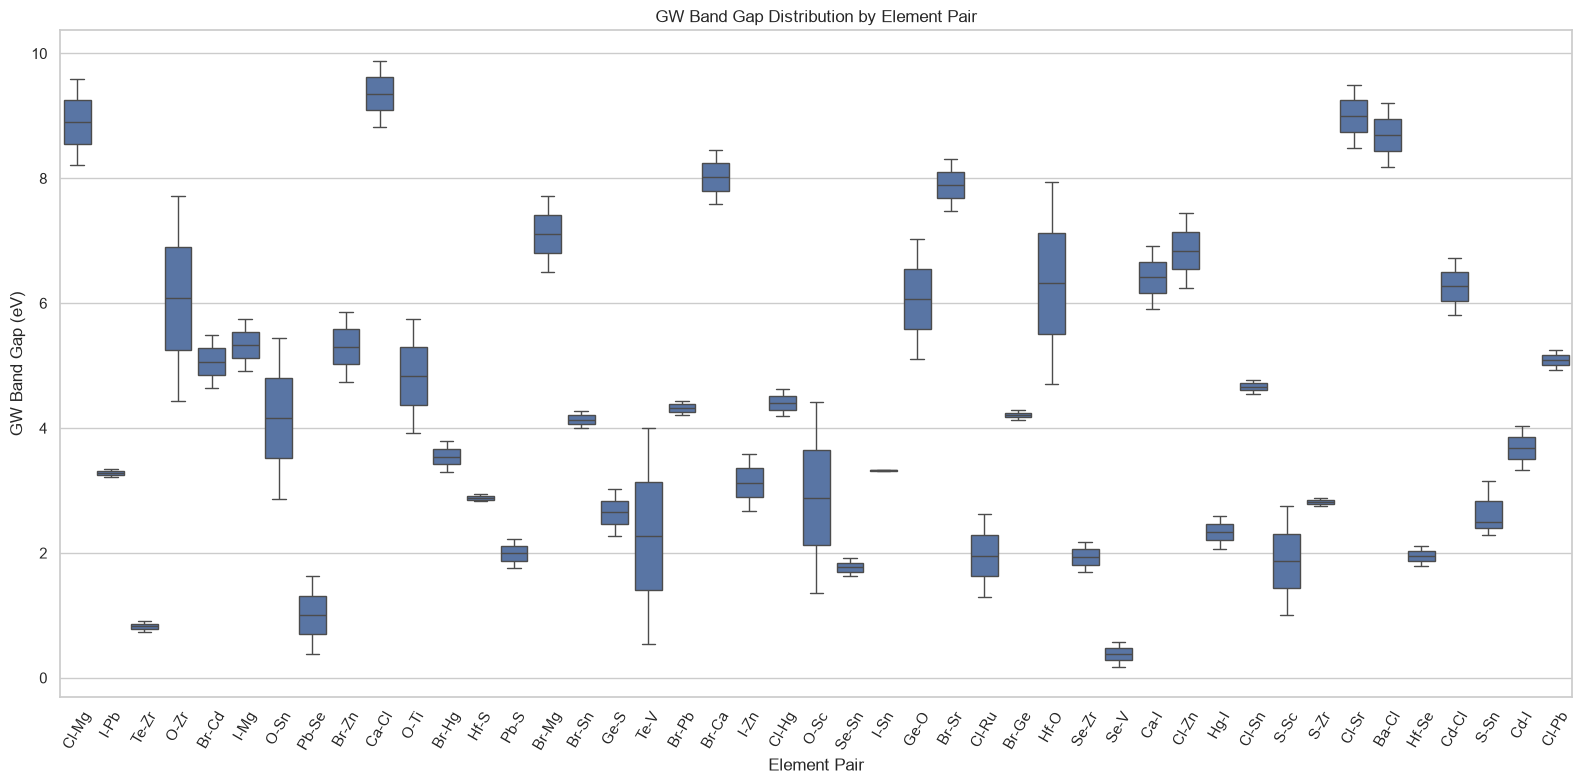

In [158]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=pair_gap_data,
    x="element_pair",
    y="gap_gw"
)

plt.xlabel("Element Pair")
plt.ylabel("GW Band Gap (eV)")
plt.title("GW Band Gap Distribution by Element Pair")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

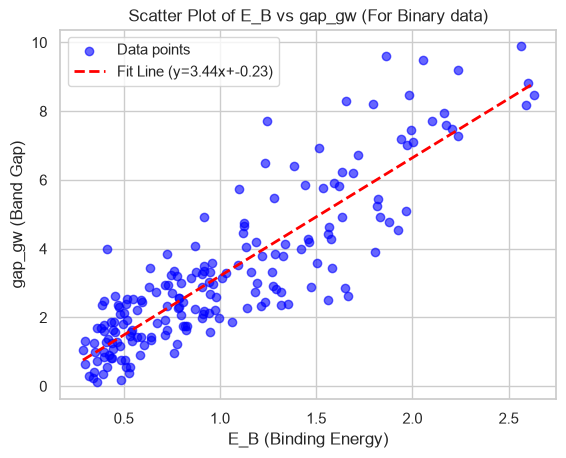

In [187]:
# Define conditions for the outlier regions
outlier_top_left = (df_binary["E_B"] < 0.25) & (df_binary["gap_gw"] > 3.5)
outlier_bottom_left = (df_binary["E_B"] < 0.2) & (df_binary["gap_gw"] < 1.0)
outlier_right = (df_binary["E_B"] > 2.0) & (df_binary["gap_gw"] < 5.0)

# Combine all outlier conditions using OR (|)
all_outliers = outlier_top_left | outlier_bottom_left | outlier_right

# Keep only the rows that are NOT outliers
d = df_binary[~all_outliers]

# Scatter plot
plt.scatter(
    d['E_B'], 
    d['gap_gw'], 
    alpha=0.6, 
    color='blue',
    label='Data points'
)   

# Calculate line of best fit (slope m and y-intercept c)
m, c = np.polyfit(d['E_B'], d['gap_gw'], 1)

# Generate x values for the regression line
x_line = np.linspace(d['E_B'].min(), d['E_B'].max(), 100)
y_line = m * x_line + c

# Plot correlation line
plt.plot(
    x_line, 
    y_line, 
    color='red', 
    linewidth=2, 
    linestyle='--', 
    label=f'Fit Line (y={m:.2f}x+{c:.2f})'
)

plt.xlabel('E_B (Binding Energy)') 
plt.ylabel('gap_gw (Band Gap)')   
plt.title('Scatter Plot of E_B vs gap_gw (For Binary data)')
plt.legend()
plt.show()


In [188]:
corr_bin_no_out = d['E_B'].corr(d['gap_gw'])
corr_bin_no_out

np.float64(0.8723230795141071)

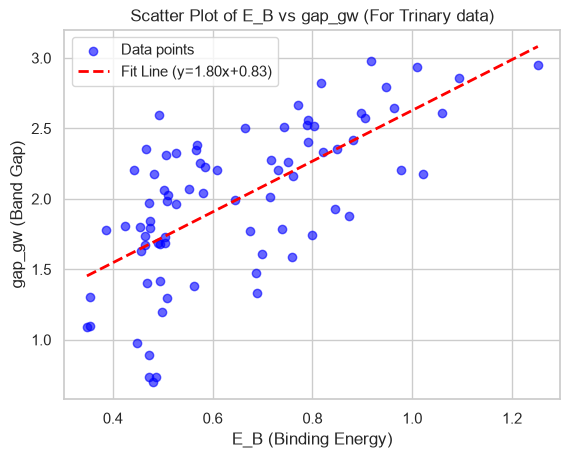

In [191]:
# Define conditions for the outlier regions
outlier_top_left = (df_binary["E_B"] < 0.25) & (df_binary["gap_gw"] > 3.5)
outlier_bottom_left = (df_binary["E_B"] < 0.2) & (df_binary["gap_gw"] < 1.0)
outlier_right = (df_binary["E_B"] > 2.0) & (df_binary["gap_gw"] < 5.0)

# Combine all outlier conditions using OR (|)
all_outliers = outlier_top_left | outlier_bottom_left | outlier_right

# Keep only the rows that are NOT outliers
d = df_trinary
# Scatter plot
plt.scatter(
    d['E_B'], 
    d['gap_gw'], 
    alpha=0.6, 
    color='blue',
    label='Data points'
)   

# Calculate line of best fit (slope m and y-intercept c)
m, c = np.polyfit(d['E_B'], d['gap_gw'], 1)

# Generate x values for the regression line
x_line = np.linspace(d['E_B'].min(), d['E_B'].max(), 100)
y_line = m * x_line + c

# Plot correlation line
plt.plot(
    x_line, 
    y_line, 
    color='red', 
    linewidth=2, 
    linestyle='--', 
    label=f'Fit Line (y={m:.2f}x+{c:.2f})'
)

plt.xlabel('E_B (Binding Energy)') 
plt.ylabel('gap_gw (Band Gap)')   
plt.title('Scatter Plot of E_B vs gap_gw (For Trinary data)')
plt.legend()
plt.show()


In [192]:
corr_bin_no_out = d['E_B'].corr(d['gap_gw'])
corr_bin_no_out

np.float64(0.659652534411882)

### ---Temp

In [159]:
import re

def get_exact_stoichiometry(formula):
    # Matches element symbols followed by optional counts
    pattern = r'([A-Z][a-z]*)(\d*)'
    matches = re.findall(pattern, str(formula))
    
    # Filter valid element matches and extract counts (default to 1 if count omitted)
    elements = [(elem, int(count) if count else 1) for elem, count in matches if elem]
    
    # Process binary formulas (exactly 2 unique elements)
    if len(elements) == 2:
        c1 = elements[0][1]
        c2 = elements[1][1]
        
        x_part = f"X{c1}" if c1 > 1 else "X"
        y_part = f"Y{c2}" if c2 > 1 else "Y"
        
        return f"{x_part}{y_part}"
    
    return None

# Apply directly to your DataFrame
df_binary['stoichiometry_type'] = df_binary['formula'].apply(get_exact_stoichiometry)

In [162]:
df_binary[['stoichiometry_type', 'formula']].head()

,stoichiometry_type,formula
2764,XY2,MgCl2
2765,XY2,MgCl2
2775,XY2,RuBr2
2782,XY2,MnCl2
2800,XY2,WTe2


In [198]:
print(df_binary['gap_gw'].mean())
print(df_trinary['gap_gw'].mean())
print(df_encoded['gap_gw'].mean())
print(df_binary['E_B'].mean())
print(df_trinary['E_B'].mean())
print(df_encoded['E_B'].mean())

3.273083913102953
1.9943508359783109
2.9019776087469524
1.077526084085227
0.6483304205928135
0.9527877528533457
